# Loading the package

This notebook will walk you through a simple usecase of Neuroprobe and evaluation of the logistic regression baseline. It can be easily adapted to evaluate any foundation model of neural activity.

In [1]:
import os
# NOTE: Change this to your own path, or define an environment variable elsewhere
os.environ['ROOT_DIR_BRAINTREEBANK'] = r'C:\Users\User\Documents\UNI\BRAIN\braintree' 

import torch
import neuroprobe.config as neuroprobe_config

# Make sure the config ROOT_DIR is set correctly
print("Expected braintreebank data at:", neuroprobe_config.ROOT_DIR)
print("Sampling rate:", neuroprobe_config.SAMPLING_RATE, "Hz")

Expected braintreebank data at: C:\Users\User\Documents\UNI\BRAIN\braintree
Sampling rate: 2048 Hz


## The BrainTreebankSubject Class

In [2]:
from neuroprobe import BrainTreebankSubject

subject_id = 10
subject_id = 3

coordinates_type = "cortical" # "cortical", "mni", "lpi". NOTE: MNI are not yet available for the Braintreebank dataset.
# cortical = standardized brain atlas cortical projection of the coordinates in Freesurfer space
# mni = MNI coordinates
# lpi = LPI coordinates (left, posterior, inferior) in the subject's coordinate system

# use cache=True to load this trial's neural data into RAM, if you have enough memory!
# It will make the loading process faster.
# subject = BrainTreebankSubject(subject_id, allow_corrupted=False, cache=True, dtype=torch.float32, coordinates_type=coordinates_type)
subject = BrainTreebankSubject(subject_id, allow_corrupted=False, cache=True, dtype=torch.float16, coordinates_type=coordinates_type)
print("Loaded subject", subject_id)
print("Electrode labels (first 10):", subject.electrode_labels[:10]) # list of electrode labels

print("\nElectrode coordinates (MNI space) of the first 10 electrodes:")
print(subject.get_electrode_coordinates()[:10]) # L, P, I coordinates of the electrodes

# Optionally, subset the electrodes to a specific set of electrodes. NOTE: you should not do this if you are using the neuroprobe as a standardized benchmark.
# subject.set_electrode_subset(['F3aOFa2', 'F3aOFa3', 'F3aOFa4', 'F3aOFa7']) # if you change this line when using cache=True, you need to clear the cache after: subject.clear_neural_data_cache()
# print("Electrode labels after subsetting:", subject.electrode_labels)

Loaded subject 3
Electrode labels (first 10): ['F2Ia1', 'F2Ia2', 'F2Ia3', 'F2Ia4', 'F2Ia5', 'F2Ia6', 'F2Ia7', 'F2Ia8', 'F2Ia9', 'F2Ia10']

Electrode coordinates (MNI space) of the first 10 electrodes:
tensor([[ 52.0625, -49.1875,  -0.2969],
        [ 52.4375, -47.6250,  -2.4238],
        [ 54.8438, -43.2812,  -5.6094],
        [ 55.2500, -38.4688,  -7.9883],
        [ 57.9375, -35.4688,  -9.0312],
        [ 59.5312, -33.7188,  -9.7734],
        [ 61.0312, -31.4531, -10.8281],
        [ 62.1875, -28.7031, -12.2031],
        [ 83.5625, -10.3203, -16.6562],
        [ 82.7500,  -7.8477, -16.5938]], dtype=torch.float16)


Loading the electrode data from a specific trial:

In [3]:
trial_id = 0

subject.load_neural_data(trial_id)
window_from = None # This is the index into the neural data array from where to start loading the data.
window_to = None # if None, the whole trial will be loaded

# all_neural_data = subject.get_all_electrode_data(trial_id, window_from=window_from, window_to=window_to)

# print("All neural data shape:")
# print(all_neural_data.shape) # (n_electrodes, n_samples). To get the data for a specific electrode, use subject.get_electrode_data(trial_id, electrode_label)

# print("\nFirst 50 samples of the first electrode (data is in microvolts):")
# print(all_neural_data[0, :50])

## The BrainTreebankSubjectTrialBenchmarkDataset Class

NOTE: In the dataset below, there will be fewer electrodes than in the full subject data. This is because the Neuroprobe benchmark only uses a subset of the electrodes for standardized and quick benchmarking. The electrode labels below are subset to the `neuroprobe_config.NEUROPROBE_LITE_ELECTRODES` list.

Accordingly, when using the `BrainTreebankSubjectTrialBenchmarkDataset` with `lite=True` (which is the default Neuroprobe benchmark option), make sure that you use the `dataset.electrode_labels` and `dataset.electrode_coordinates` properties, which give the electrode labels and the electrode coordinates in MNI space, respectively, in the exact order that the `dataset` will output the data tensors in.

In [4]:
from neuroprobe import BrainTreebankSubjectTrialBenchmarkDataset

# Options for eval_name (from the Neuroprobe paper): neuroprobe_config.EVAL_NAMES
#   frame_brightness, global_flow, local_flow, face_num, volume, pitch, delta_volume, 
#   speech, onset, scene_onset, gpt2_surprisal, word_length, word_gap, word_index, word_head_pos, word_part_speech, speaker
eval_name = "frame_brightness"  # Try "scene_onset" to detect scene changes in the movie
eval_name = "delta_delta_frame_brightness_abs"
eval_name = "speaker"
eval_name = "speaker_gender"
eval_name = "scene"
# eval_name = "scene_onset"

# if True, the dataset will output the indices of the samples in the neural data in a tuple: (index_from, index_to); 
# if False, the dataset will output the neural data directly
output_indices = False

start_neural_data_before_word_onset = 0 # the number of samples to start the neural data before each word onset
end_neural_data_after_word_onset = neuroprobe_config.SAMPLING_RATE * 1 # the number of samples to end the neural data after each word onset -- here we use 1 second

dataset = BrainTreebankSubjectTrialBenchmarkDataset(subject, trial_id, dtype=torch.float32, eval_name=eval_name, output_indices=output_indices, 
                                                    start_neural_data_before_word_onset=start_neural_data_before_word_onset, end_neural_data_after_word_onset=end_neural_data_after_word_onset,
                                                    lite=True) # the default is Neuroprobe Lite for standardized and quick benchmarking. Feel free to set lite=false if trying to access the Full dataset.
# P.S. Allow partial cache -- whether to allow partial caching of the neural data, if only part of it is needed for this particular dataset. Better set to False when doing multiple evals back to back, but better set to True when doing a single eval.

data_electrode_labels = dataset.electrode_labels # NOTE: this is different from the subject.electrode_labels! Neuroprobe uses a special subset of electrodes in this exact order.
data_electrode_coordinates = dataset.electrode_coordinates 

# print("Items in the dataset:", len(dataset), "\n")
# print(f"The first item: (shape = {dataset[0][0].shape})", dataset[0][0], f"label = {dataset[0][1]}", sep="\n")
first_item = dataset[0]
if isinstance(first_item, dict):
    data = first_item["data"]
    label = first_item["label"]
else:
    data, label = first_item

print("Items in the dataset:", len(dataset), "\n")
print(f"The first item: (shape = {data.shape})", data, f"label = {label}", sep="\n")
print("")
print(f"Electrode labels in the data above in the following order ({len(data_electrode_labels)} electrodes):", data_electrode_labels)
print(f"Electrode coordinates in the data above in the following order ({len(data_electrode_coordinates)} electrodes):", data_electrode_coordinates)

Items in the dataset: 1204 

The first item: (shape = torch.Size([109, 2048]))
tensor([[-11.6971, -13.2921,  -9.5703,  ...,  -0.7975,  -2.9243,  -0.2658],
        [ 30.0402,  28.1793,  27.3818,  ...,  10.1020,   5.8485,   4.5193],
        [  0.7975,   0.2658,   0.2658,  ..., -17.5456, -20.2040, -21.0016],
        ...,
        [ 16.2164,  15.1530,  13.8238,  ..., -43.0665, -46.5225, -46.2566],
        [ 44.1299,  44.3957,  47.5858,  ...,  10.8995,   9.5703,  10.1020],
        [  7.1778,   4.7852,   7.4436,  ..., -19.1407, -22.0649, -19.4065]])
label = 1

Electrode labels in the data above in the following order (109 electrodes): ['T1cIe5', 'T1cIe6', 'T1cIe7', 'T1cIe8', 'T1cIe9', 'T1cIe10', 'T1cIe11', 'T1cIe12', 'T1b1', 'T1b2', 'T1b3', 'T1b4', 'T1b5', 'T1b6', 'T1aIc3', 'T1aIc4', 'T1aIc5', 'T1aIc6', 'O1aIb9', 'O1aIb10', 'O1aIb11', 'O1aIb12', 'O1aIb13', 'O1aIb14', 'O1aIb15', 'O1aIb16', 'F3d1', 'F3d2', 'F3d3', 'F3d4', 'F3d5', 'F3d6', 'F3d7', 'F3d8', 'F3d9', 'F3d10', 'F3aOF1', 'F3aOF2', 'F3a

In [6]:
# Optionally, you can request the output_dict=True to get the data as a dictionary with a bunch of metadata.
dataset.output_dict = True
print(dataset[0])

dataset.output_dict = False # set it back

{'data': tensor([[-11.6971, -13.2921,  -9.5703,  ...,  -0.7975,  -2.9243,  -0.2658],
        [ 30.0402,  28.1793,  27.3818,  ...,  10.1020,   5.8485,   4.5193],
        [  0.7975,   0.2658,   0.2658,  ..., -17.5456, -20.2040, -21.0016],
        ...,
        [ 16.2164,  15.1530,  13.8238,  ..., -43.0665, -46.5225, -46.2566],
        [ 44.1299,  44.3957,  47.5858,  ...,  10.8995,   9.5703,  10.1020],
        [  7.1778,   4.7852,   7.4436,  ..., -19.1407, -22.0649, -19.4065]]), 'label': 1, 'electrode_labels': ['T1cIe5', 'T1cIe6', 'T1cIe7', 'T1cIe8', 'T1cIe9', 'T1cIe10', 'T1cIe11', 'T1cIe12', 'T1b1', 'T1b2', 'T1b3', 'T1b4', 'T1b5', 'T1b6', 'T1aIc3', 'T1aIc4', 'T1aIc5', 'T1aIc6', 'O1aIb9', 'O1aIb10', 'O1aIb11', 'O1aIb12', 'O1aIb13', 'O1aIb14', 'O1aIb15', 'O1aIb16', 'F3d1', 'F3d2', 'F3d3', 'F3d4', 'F3d5', 'F3d6', 'F3d7', 'F3d8', 'F3d9', 'F3d10', 'F3aOF1', 'F3aOF2', 'F3aOF3', 'F3aOF4', 'F3aOF5', 'F3aOF6', 'F3aOF7', 'F3aOF8', 'F3c1', 'F3c2', 'F3c3', 'F3c4', 'F3c5', 'F3c6', 'F2Ia1', 'F2Ia2', 'F

In [7]:
# Also, you can request only the indices into the neural data array, instead of the actual data.
# NOTE: These are the indices into the data as in the raw h5 files in the braintreebank dataset.

dataset.output_indices = True
print(dataset[0]) # Data format: (index_from, index_to), label

dataset.output_indices = False # set it back

((1170912, 1172960), 1)


## Train/Test Splits

In this example, we generate train/test splits for the WithinSession evaluation.

All options: generate_splits_within_session, generate_splits_cross_session, generate_splits_cross_subject

In [8]:
import neuroprobe.train_test_splits as neuroprobe_train_test_splits

folds = neuroprobe_train_test_splits.generate_splits_within_session(subject, trial_id, eval_name, dtype=torch.float32, 
                                                                                # Put the dataset parameters here
                                                                                output_indices=output_indices, start_neural_data_before_word_onset=start_neural_data_before_word_onset, end_neural_data_after_word_onset=end_neural_data_after_word_onset,
                                                                                lite=True)
print("len(folds) = k_folds =", len(folds))
folds

len(folds) = k_folds = 2


[{'train_dataset': <torch.utils.data.dataset.Subset at 0x1ef2f2f5fc0>,
  'val_dataset': <torch.utils.data.dataset.Subset at 0x1ef2f4683d0>,
  'test_dataset': <torch.utils.data.dataset.Subset at 0x1ef2f468880>},
 {'train_dataset': <torch.utils.data.dataset.Subset at 0x1ef5b57f340>,
  'val_dataset': <torch.utils.data.dataset.Subset at 0x1ef5b57edd0>,
  'test_dataset': <torch.utils.data.dataset.Subset at 0x1ef5b57fca0>}]

## Example Linear Regression on SS_SM

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np

for fold_idx, fold in enumerate(folds):
    print(f"Fold {fold_idx+1} of {len(folds)}")
    train_dataset = fold["train_dataset"]
    test_dataset = fold["test_dataset"]

    train_dataset.dataset.output_dict = False
    test_dataset.dataset.output_dict = False

    # Convert PyTorch dataset to numpy arrays for scikit-learn
    X_train = np.array([item[0].flatten() for item in train_dataset])
    y_train = np.array([item[1] for item in train_dataset])
    X_test = np.array([item[0].flatten() for item in test_dataset])
    y_test = np.array([item[1] for item in test_dataset])

    # Standardize the data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Train logistic regression
    clf = LogisticRegression(random_state=42, max_iter=1000, tol=1e-3)
    clf.fit(X_train, y_train)

    # Evaluate model
    train_score = clf.score(X_train, y_train)
    test_score = clf.score(X_test, y_test)
    print(f"\t Train accuracy: {train_score:.3f} | Test accuracy: {test_score:.3f}")

Fold 1 of 2
	 Train accuracy: 1.000 | Test accuracy: 0.425
Fold 2 of 2
	 Train accuracy: 1.000 | Test accuracy: 0.571


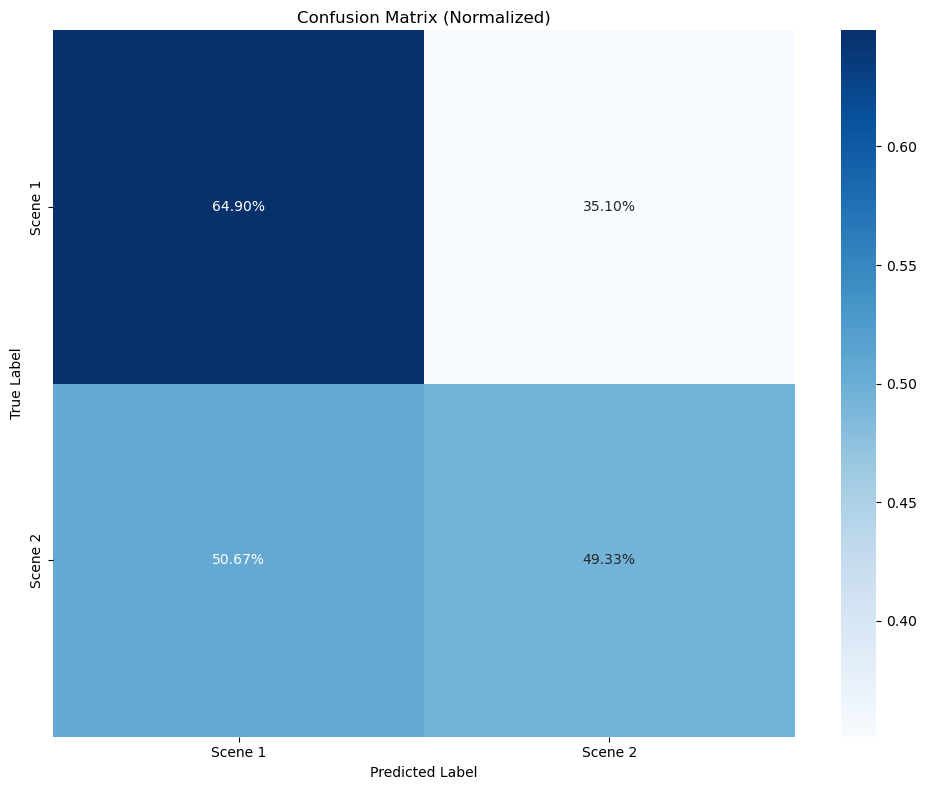

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
class_names = ["Female", "Male"]
class_names = ["Scene 1", "Scene 2"]
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# Normalize to percentages
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix (Normalized)')
plt.tight_layout()
plt.show()

In [14]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

for fold_idx, fold in enumerate(folds):
    print(f"Fold {fold_idx+1} of {len(folds)}")
    train_dataset = fold["train_dataset"]
    test_dataset = fold["test_dataset"]

    train_dataset.dataset.output_dict = False
    test_dataset.dataset.output_dict = False

    # Convert PyTorch dataset to numpy arrays for scikit-learn
    X_train = np.array([item[0].flatten() for item in train_dataset])
    y_train = np.array([item[1] for item in train_dataset])
    X_test = np.array([item[0].flatten() for item in test_dataset])
    y_test = np.array([item[1] for item in test_dataset])

    # Standardize the data
    # scaler = StandardScaler()
    # X_train = scaler.fit_transform(X_train)
    # X_test = scaler.transform(X_test)

    # Train logistic regression
    # clf = 
    # clf.fit(X_train, y_train)

    # Fit scaler incrementally on training data
    scaler = StandardScaler()
    batch_size = 200  # Adjust based on your memory
    
    print("  Fitting scaler incrementally...")
    for i in range(0, len(train_dataset), batch_size):
        batch = [train_dataset[j] for j in range(i, min(i+batch_size, len(train_dataset)))]
        X_batch = np.array([item[0].flatten() for item in batch], dtype=np.float32)
        scaler.partial_fit(X_batch)
    
    # Train classifier incrementally using SGD
    # clf = LogisticRegression(random_state=42, max_iter=1000, tol=1e-3)
    clf = SGDClassifier(loss='log_loss', random_state=42, max_iter=1000, tol=1e-3, learning_rate='adaptive')

    
    print("  Training classifier incrementally...")
    for i in range(0, len(train_dataset), batch_size):
        batch = [train_dataset[j] for j in range(i, min(i+batch_size, len(train_dataset)))]
        X_batch = np.array([item[0].flatten() for item in batch], dtype=np.float32)
        y_batch = np.array([item[1] for item in batch])
        X_batch_std = scaler.transform(X_batch)
        clf.partial_fit(X_batch_std, y_batch, classes=np.unique(y_batch))
    

    # Evaluate model
    train_score = clf.score(X_train, y_train)
    test_score = clf.score(X_test, y_test)
    print(f"\t Train accuracy: {train_score:.3f} | Test accuracy: {test_score:.3f}")

Fold 1 of 2


MemoryError: Unable to allocate 850. MiB for an array with shape (907, 245760) and data type float32

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

for fold_idx, fold in enumerate(folds):
    print(f"Fold {fold_idx+1} of {len(folds)}")
    train_dataset = fold["train_dataset"]
    test_dataset = fold["test_dataset"]

    train_dataset.dataset.output_dict = False
    test_dataset.dataset.output_dict = False

    # Convert PyTorch dataset to numpy arrays for scikit-learn
    X_train = np.array([item[0].flatten() for item in train_dataset])
    y_train = np.array([item[1] for item in train_dataset])
    X_test = np.array([item[0].flatten() for item in test_dataset])
    y_test = np.array([item[1] for item in test_dataset])

    # Standardize the data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    dummy_clf = DummyClassifier(strategy="uniform", random_state=42)
    dummy_clf.fit(X_train, y_train)  # This just learns the class distribution
    train_score = dummy_clf.score(X_train, y_train)
    test_score = dummy_clf.score(X_test, y_test)

    # Or most frequent class baseline
    dummy_clf = DummyClassifier(strategy="most_frequent", random_state=42)
    dummy_clf.fit(X_train, y_train)
    train_score = dummy_clf.score(X_train, y_train)
    test_score = dummy_clf.score(X_test, y_test)
    print("No training")
    print(f"\t Train accuracy: {train_score:.3f} | Test accuracy: {test_score:.3f}")

Fold 1 of 2
No training
	 Train accuracy: 0.500 | Test accuracy: 0.502
Fold 2 of 2
No training
	 Train accuracy: 0.500 | Test accuracy: 0.502


Top 10 most important electrodes:
  F2Ia12: 0.0033
  F2Ia3: 0.0017
  T1cIe6: 0.0016
  F3b8: 0.0015
  T1cIe7: 0.0015
  F2Ia4: 0.0014
  F2Ia2: 0.0013
  F2Ia11: 0.0013
  F3aOF7: 0.0012
  O1bId9: 0.0012


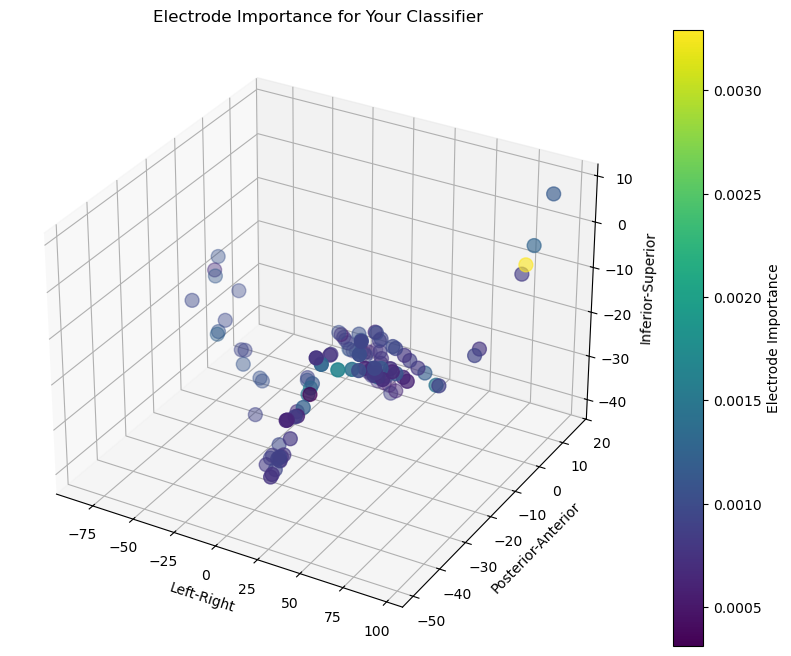

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np

# After training your classifier
# clf = LogisticRegression()
# clf.fit(X_train, y_train)

# Get coefficients (weights)
# For binary classification: clf.coef_ is shape (1, n_features)
# For multi-class: clf.coef_ is shape (n_classes, n_features)
coef = clf.coef_[0]  # Shape: (n_electrodes * n_time_samples,)

# Reshape to (n_electrodes, n_time_samples)
n_electrodes = len(dataset.electrode_labels)
n_time_samples = X_train.shape[1] // n_electrodes  # or however you structured your data
coef_reshaped = coef.reshape(n_electrodes, n_time_samples)

# Aggregate across time: mean absolute weight per electrode
electrode_importance = np.mean(np.abs(coef_reshaped), axis=1)

# Create mapping: electrode_label -> importance
electrode_importance_dict = {
    label: importance 
    for label, importance in zip(dataset.electrode_labels, electrode_importance)
}

# Sort by importance
sorted_electrodes = sorted(electrode_importance_dict.items(), key=lambda x: x[1], reverse=True)
print("Top 10 most important electrodes:")
for electrode, importance in sorted_electrodes[:10]:
    print(f"  {electrode}: {importance:.4f}")

# Get electrode coordinates
electrode_coords = dataset.electrode_coordinates  # Shape: (n_electrodes, 3) - MNI coordinates

# Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Color by importance
colors = electrode_importance / electrode_importance.max()
scatter = ax.scatter(
    electrode_coords[:, 0],  # X (Left-Right)
    electrode_coords[:, 1],  # Y (Posterior-Anterior)  
    electrode_coords[:, 2],  # Z (Inferior-Superior)
    c=electrode_importance,
    cmap='viridis',
    s=100
)

plt.colorbar(scatter, label='Electrode Importance')
ax.set_xlabel('Left-Right')
ax.set_ylabel('Posterior-Anterior')
ax.set_zlabel('Inferior-Superior')
plt.title('Electrode Importance for Your Classifier')
plt.show()

# Spectrogram

In [19]:
subject

In [ ]:
from eval_utils import preprocess_data, preprocess_stft
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
import numpy as np
from neuroprobe import BrainTreebankSubjectTrialBenchmarkDataset

# Options for eval_name (from the Neuroprobe paper): neuroprobe_config.EVAL_NAMES
#   frame_brightness, global_flow, local_flow, face_num, volume, pitch, delta_volume, 
#   speech, onset, scene_onset, gpt2_surprisal, word_length, word_gap, word_index, word_head_pos, word_part_speech, speaker


# if True, the dataset will output the indices of the samples in the neural data in a tuple: (index_from, index_to); 
# if False, the dataset will output the neural data directly
output_indices = False

start_neural_data_before_word_onset = 0 # the number of samples to start the neural data before each word onset
end_neural_data_after_word_onset = neuroprobe_config.SAMPLING_RATE * 1 # the number of samples to end the neural data after each word onset -- here we use 1 second


# Set up STFT parameters
preprocess_parameters = {
    "stft": {
        "nperseg": 512,        # Window length
        "poverlap": 0.75,      # 75% overlap
        "window": "hann",       # Hann window
        "max_frequency": 150,   # Max frequency to keep
        "min_frequency": 0     # Min frequency to keep
    }
}
eval_name = "volume"
# Load your dataset
# dataset = BrainTreebankSubjectTrialBenchmarkDataset(
#     subject, trial_id, dtype=torch.float32, 
#     eval_name=eval_name,  # e.g., "pitch", "volume", etc.
#     output_indices=False
# )

dataset = BrainTreebankSubjectTrialBenchmarkDataset(
    subject, trial_id, dtype=torch.float16, 
    eval_name=eval_name,  # e.g., "pitch", "volume", etc.
    output_indices=False
)

# Collect data
X_data = []
y_data = []
for i in range(len(dataset)):
    item = dataset[i]
    if isinstance(item, dict):
        neural_data = item['data']  # Shape: (n_electrodes, n_samples)
        label = item['label']
    else:
        neural_data, label = item
    
    X_data.append(neural_data.numpy())
    y_data.append(label)

X_data = np.array(X_data)  # Shape: (n_samples, n_electrodes, n_time_samples)
y_data = np.array(y_data)

In [8]:
import torch

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_spectrogram_batches = []
batch_size = 50

for i in range(0, len(X_data), batch_size):
    batch = X_data[i:i+batch_size]
    batch_tensor = torch.from_numpy(batch).to(device)  # Move to GPU
    
    # preprocess_stft will use the device of the input tensor
    batch_spectrogram = preprocess_stft(
        batch_tensor,  # Already on GPU
        sampling_rate=2048,
        preprocess="stft_abs",
        preprocess_parameters=preprocess_parameters
    )
    
    # Move back to CPU and convert to numpy
    if isinstance(batch_spectrogram, torch.Tensor):
        batch_spectrogram = batch_spectrogram.cpu().numpy()
    
    X_spectrogram_batches.append(batch_spectrogram)

X_spectrogram = np.concatenate(X_spectrogram_batches, axis=0)

In [9]:
# Convert to spectrogram
# Input: (n_samples, n_electrodes, n_time_samples)
# Output: (n_samples, n_electrodes, n_timebins, n_freqs)
# X_spectrogram = preprocess_stft(
#     X_data, 
#     sampling_rate=2048,
#     preprocess="stft_abs",  # Use magnitude spectrogram
#     preprocess_parameters=preprocess_parameters
# )

print(f"Spectrogram shape: {X_spectrogram.shape}")
# Shape: (n_samples, n_electrodes, n_timebins, n_freqs)

Spectrogram shape: (3500, 109, 17, 38)


In [10]:
# Flatten spectrogram: (n_samples, n_electrodes, n_timebins, n_freqs) 
# -> (n_samples, n_electrodes * n_timebins * n_freqs)
n_samples = X_spectrogram.shape[0]
X_flat = X_spectrogram.reshape(n_samples, -1)

print(f"Flattened shape: {X_flat.shape}")
# Shape: (n_samples, n_electrodes * n_timebins * n_freqs)

Flattened shape: (3500, 70414)


In [12]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Use partial_fit for fitting
scaler = StandardScaler()
batch_size = 100

# Fit scaler incrementally
for i in range(0, len(X_train), batch_size):
    scaler.partial_fit(X_train[i:i+batch_size])

# Transform in batches
def transform_in_batches(X, scaler, batch_size=100):
    batches = []
    for i in range(0, len(X), batch_size):
        batch = scaler.transform(X[i:i+batch_size])
        batches.append(batch)
    return np.vstack(batches)

X_train_scaled = transform_in_batches(X_train, scaler, batch_size)
X_test_scaled = transform_in_batches(X_test, scaler, batch_size)

In [13]:
# Split into train/test
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(
#     X_flat, y_data, test_size=0.2, random_state=42
# )

# Scale features (important for linear regression)
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# Train linear regression
# For regression tasks (continuous outputs)
reg = LinearRegression()
# Or use Ridge for regularization:
# reg = Ridge(alpha=1.0)

reg.fit(X_train_scaled, y_train)

# Predict
y_pred = reg.predict(X_test_scaled)

# Evaluate
from sklearn.metrics import r2_score, mean_squared_error
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"R² score: {r2:.4f}")
print(f"MSE: {mse:.4f}")

R² score: 0.4472
MSE: 0.1382


In [14]:
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression

# Train your classifier
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

# Get probability predictions (not just class predictions)
y_train_probs = clf.predict_proba(X_train_scaled)
y_test_probs = clf.predict_proba(X_test_scaled)

# For binary classification, use the positive class probabilities
# y_probs[:, 1] gives probabilities for class 1
train_auroc = roc_auc_score(y_train, y_train_probs[:, 1])
test_auroc = roc_auc_score(y_test, y_test_probs[:, 1])

print(f"Train AUROC: {train_auroc:.4f}")
print(f"Test AUROC: {test_auroc:.4f}")

Train AUROC: 1.0000
Test AUROC: 0.9036


In [17]:
subject_id = 10

coordinates_type = "cortical" # "cortical", "mni", "lpi". NOTE: MNI are not yet available for the Braintreebank dataset.
# cortical = standardized brain atlas cortical projection of the coordinates in Freesurfer space
# mni = MNI coordinates
# lpi = LPI coordinates (left, posterior, inferior) in the subject's coordinate system

# use cache=True to load this trial's neural data into RAM, if you have enough memory!
# It will make the loading process faster.
# subject = BrainTreebankSubject(subject_id, allow_corrupted=False, cache=True, dtype=torch.float32, coordinates_type=coordinates_type)
subject10 = BrainTreebankSubject(subject_id, allow_corrupted=False, cache=True, dtype=torch.float16, coordinates_type=coordinates_type)

In [22]:
import os
import torch
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score
import matplotlib.pyplot as plt

from neuroprobe import BrainTreebankSubject, BrainTreebankSubjectTrialBenchmarkDataset
# from examples.eval_utils import preprocess_data

# 1. Load subject 10
# subject_id = 10
trial_id = 0  # or 1, or both
# eval_name = "volume"  # or whatever task you trained on
binary_tasks = True


print(f"Number of electrodes: {len(subject10.electrode_labels)}")

# 2. Create test dataset from subject 10 (NO train/test split - this is pure test data)
test_dataset = BrainTreebankSubjectTrialBenchmarkDataset(
    subject10, 
    trial_id=trial_id,
    dtype=torch.float32,
    eval_name=eval_name,
    binary_tasks=binary_tasks,
    output_indices=False,
    lite=True
)

print(f"Test dataset size: {len(test_dataset)}")

# 3. Extract ALL data from subject 10 (this is your test set)
# Time window: 0-1 second after word onset
data_idx_from = int(0 * 2048)  # 0 seconds before onset
data_idx_to = int(1 * 2048)    # 1 second after onset

# Preprocessing parameters (must match your training preprocessing)
preprocess_parameters = {
    "stft": {
        "nperseg": 512,
        "poverlap": 0.75,
        "window": "hann",
        "max_frequency": 150,
        "min_frequency": 0
    }
}


# Collect data
# X_data = []
# y_data = []
# for i in range(len(dataset)):
#     item = dataset[i]
#     if isinstance(item, dict):
#         neural_data = item['data']  # Shape: (n_electrodes, n_samples)
#         label = item['label']
#     else:
#         neural_data, label = item
    
#     X_data.append(neural_data.numpy())
#     y_data.append(label)

# X_data = np.array(X_data)  # Shape: (n_samples, n_electrodes, n_time_samples)
# y_data = np.array(y_data)


# Extract test data from subject 10
print("Extracting test data from subject 10...")
X_test_subj10 = []
y_test_subj10 = []
for i in range(len(test_dataset)):
    item = test_dataset[i]
    if isinstance(item, dict):
        neural_data = item['data']  # Shape: (n_electrodes, n_samples)
        label = item['label']
    else:
        neural_data, label = item
    
    X_test_subj10.append(neural_data.numpy())
    y_test_subj10.append(label)

X_test_subj10 = np.array(X_test_subj10)  # Shape: (n_samples, n_electrodes, n_time_samples)
y_test_subj10 = np.array(y_test_subj10)


# # Extract test data from subject 10
# print("Extracting test data from subject 10...")
# X_test_subj10 = []
# y_test_subj10 = []
# for item in test_dataset:
#     neural_data = item[0][:, data_idx_from:data_idx_to].unsqueeze(0)
#     label = item[1]
#     X_test_subj10.append(neural_data)
#     y_test_subj10.append(label)

# X_test_subj10 = torch.cat(X_test_subj10, dim=0)  # (n_samples, n_electrodes, n_time_samples)
# y_test_subj10 = np.array(y_test_subj10)

print(f"Test data shape: {X_test_subj10.shape}")
print(f"Test labels shape: {y_test_subj10.shape}")
print(f"Label distribution: {np.bincount(y_test_subj10)}")

# 4. Preprocess to spectrogram (same preprocessing as training)
print("Preprocessing to spectrogram...")
X_test_subj10_spectrogram = preprocess_data(
    X_test_subj10,
    subject.electrode_labels,
    preprocess_type="stft_abs",
    preprocess_parameters=preprocess_parameters
).float().numpy()

# Flatten spectrogram features
X_test_subj10_flat = X_test_subj10_spectrogram.reshape(X_test_subj10_spectrogram.shape[0], -1)
print(f"Test features shape: {X_test_subj10_flat.shape}")

# 5. Apply the SAME scaler from training (you need to have this from your training)
# IMPORTANT: Use the scaler that was fit on TRAINING data (from another subject)
# X_test_subj10_scaled = scaler.transform(X_test_subj10_flat)  # Use your trained scaler here

# 6. Evaluate with your trained classifier
# y_test_pred = clf.predict(X_test_subj10_scaled)
# y_test_proba = clf.predict_proba(X_test_subj10_scaled)

# 7. Calculate ROC
# test_accuracy = accuracy_score(y_test_subj10, y_test_pred)
# test_auroc = roc_auc_score(y_test_subj10, y_test_proba[:, 1])  # for binary classification

# print(f"\nSubject 10 Test Accuracy: {test_accuracy:.4f}")
# print(f"Subject 10 Test AUROC: {test_auroc:.4f}")

# 8. Plot ROC curve (for binary classification)
# if len(np.unique(y_test_subj10)) == 2:
#     fpr_test, tpr_test, _ = roc_curve(y_test_subj10, y_test_proba[:, 1])
#     
#     plt.figure(figsize=(8, 6))
#     plt.plot(fpr_test, tpr_test, label=f'Subject 10 Test (AUC = {test_auroc:.3f})', linewidth=2)
#     plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
#     plt.xlabel('False Positive Rate', fontsize=12)
#     plt.ylabel('True Positive Rate', fontsize=12)
#     plt.title(f'ROC Curve - Subject 10, Trial {trial_id}, Task: {eval_name}', fontsize=14)
#     plt.legend(fontsize=11)
#     plt.grid(alpha=0.3)
#     plt.tight_layout()
#     plt.show()

Number of electrodes: 205
Test dataset size: 3500
Extracting test data from subject 10...


RuntimeError: [enforce fail at alloc_cpu.cpp:114] data. DefaultCPUAllocator: not enough memory: you tried to allocate 983040 bytes.

In [21]:
test_dataset

In [ ]:
# If you already have clf and scaler trained on another subject:
# Just extract and preprocess subject 10 data, then evaluate

# Extract test data from subject 10
dataset = BrainTreebankSubjectTrialBenchmarkDataset(
    subject, trial_id, dtype=torch.float16, 
    eval_name=eval_name,  # e.g., "pitch", "volume", etc.
    output_indices=False
)

# Collect data
X_data = []
y_data = []
for i in range(len(dataset)):
    item = dataset[i]
    if isinstance(item, dict):
        neural_data = item['data']  # Shape: (n_electrodes, n_samples)
        label = item['label']
    else:
        neural_data, label = item
    
    X_data.append(neural_data.numpy())
    y_data.append(label)

X_data = np.array(X_data)  # Shape: (n_samples, n_electrodes, n_time_samples)
y_data = np.array(y_data)


X_test_subj10 = []
y_test_subj10 = []
for item in test_dataset:
    neural_data = item[0][:, data_idx_from:data_idx_to].unsqueeze(0)
    label = item[1]
    X_test_subj10.append(neural_data)
    y_test_subj10.append(label)

X_test_subj10 = torch.cat(X_test_subj10, dim=0)
y_test_subj10 = np.array(y_test_subj10)

# Preprocess
X_test_subj10_spectrogram = preprocess_data(
    X_test_subj10,
    subject.electrode_labels,
    preprocess_type="stft_abs",
    preprocess_parameters=preprocess_parameters
).float().numpy()

X_test_subj10_flat = X_test_subj10_spectrogram.reshape(X_test_subj10_spectrogram.shape[0], -1)

# Apply scaler (from training)
X_test_subj10_scaled = scaler.transform(X_test_subj10_flat)

# Evaluate
y_test_pred = clf.predict(X_test_subj10_scaled)
y_test_proba = clf.predict_proba(X_test_subj10_scaled)

test_accuracy = accuracy_score(y_test_subj10, y_test_pred)
test_auroc = roc_auc_score(y_test_subj10, y_test_proba[:, 1])  # for binary

print(f"Subject 10 Test Accuracy: {test_accuracy:.4f}")
print(f"Subject 10 Test AUROC: {test_auroc:.4f}")

In [10]:
# from neuroprobe import BrainTreebankSubjectTrialBenchmarkDataset
# import numpy as np

# dataset_onset = BrainTreebankSubjectTrialBenchmarkDataset(
#     subject,
#     trial_id,
#     dtype=torch.float32,
#     eval_name="onset",
#     output_indices=False,
#     start_neural_data_before_word_onset=start_neural_data_before_word_onset,
#     end_neural_data_after_word_onset=end_neural_data_after_word_onset,
#     lite=True,
#     output_dict=False,
# )

# X_onset = np.array([item[0].flatten() for item in dataset_onset])
# y_onset = np.array([item[1] for item in dataset_onset])

# X_onset_std = scaler.transform(X_onset.astype(np.float32))
# acc_onset = clf.score(X_onset_std, y_onset)
# probs_onset = clf.predict_proba(X_onset_std)

# print(f"Overall accuracy on onset set: {acc_onset:.3f}")
# print("First five probability vectors:", probs_onset[:5])

In [18]:
## Check if the Neural Data Samples are Identical

from neuroprobe import BrainTreebankSubjectTrialBenchmarkDataset
import numpy as np

# Load both datasets with output_indices=True to compare which samples they use
dataset_onset_indices = BrainTreebankSubjectTrialBenchmarkDataset(
    subject, trial_id, dtype=torch.float32, eval_name="onset",
    output_indices=True,  # Get indices instead of data
    start_neural_data_before_word_onset=start_neural_data_before_word_onset,
    end_neural_data_after_word_onset=end_neural_data_after_word_onset,
    lite=True, output_dict=False
)

dataset_scene_indices = BrainTreebankSubjectTrialBenchmarkDataset(
    subject, trial_id, dtype=torch.float32, eval_name="scene_onset",
    output_indices=True,
    start_neural_data_before_word_onset=start_neural_data_before_word_onset,
    end_neural_data_after_word_onset=end_neural_data_after_word_onset,
    lite=True, output_dict=False
)

# Get all indices and labels
onset_indices = [dataset_onset_indices[i][0] for i in range(len(dataset_onset_indices))]
onset_labels = [dataset_onset_indices[i][1] for i in range(len(dataset_onset_indices))]

scene_indices = [dataset_scene_indices[i][0] for i in range(len(dataset_scene_indices))]
scene_labels = [dataset_scene_indices[i][1] for i in range(len(dataset_scene_indices))]

# Find overlapping time windows (same neural data windows)
onset_index_set = set(onset_indices)
scene_index_set = set(scene_indices)
overlapping_indices = onset_index_set & scene_index_set

print(f"Onset dataset: {len(onset_indices)} samples")
print(f"Scene_onset dataset: {len(scene_indices)} samples")
print(f"Overlapping time windows: {len(overlapping_indices)} samples")
print(f"Overlap percentage: {len(overlapping_indices) / max(len(onset_indices), len(scene_indices)) * 100:.1f}%")

# Now check if the actual neural data is identical for overlapping samples
if len(overlapping_indices) > 0:
    # Load actual data
    dataset_onset_data = BrainTreebankSubjectTrialBenchmarkDataset(
        subject, trial_id, dtype=torch.float32, eval_name="onset",
        output_indices=False,
        start_neural_data_before_word_onset=start_neural_data_before_word_onset,
        end_neural_data_after_word_onset=end_neural_data_after_word_onset,
        lite=True, output_dict=False
    )
    
    dataset_scene_data = BrainTreebankSubjectTrialBenchmarkDataset(
        subject, trial_id, dtype=torch.float32, eval_name="scene_onset",
        output_indices=False,
        start_neural_data_before_word_onset=start_neural_data_before_word_onset,
        end_neural_data_after_word_onset=end_neural_data_after_word_onset,
        lite=True, output_dict=False
    )
    
    # Create mapping from indices to positions
    onset_idx_to_pos = {idx: i for i, idx in enumerate(onset_indices)}
    scene_idx_to_pos = {idx: i for i, idx in enumerate(scene_indices)}
    
    # Check if neural data is identical for overlapping samples
    sample_size = min(100, len(overlapping_indices))  # Check first 100 overlapping samples
    overlapping_list = list(overlapping_indices)[:sample_size]
    
    data_identical_count = 0
    data_different_count = 0
    
    for idx in overlapping_list:
        onset_pos = onset_idx_to_pos[idx]
        scene_pos = scene_idx_to_pos[idx]
        
        # Get the actual neural data
        onset_data = dataset_onset_data[onset_pos][0].flatten().numpy()
        scene_data = dataset_scene_data[scene_pos][0].flatten().numpy()
        
        # Check if they're identical
        if np.array_equal(onset_data, scene_data):
            data_identical_count += 1
        else:
            data_different_count += 1
    
    print(f"\n{'='*60}")
    print(f"Neural Data Comparison (first {sample_size} overlapping samples):")
    print(f"{'='*60}")
    print(f"Identical neural data: {data_identical_count}/{sample_size} ({data_identical_count/sample_size*100:.1f}%)")
    print(f"Different neural data: {data_different_count}/{sample_size} ({data_different_count/sample_size*100:.1f}%)")
    
    if data_identical_count == sample_size:
        print("\n⚠️  WARNING: All overlapping samples have IDENTICAL neural data!")
        print("   This means the classifiers are seeing the exact same input features.")
        print("   If the labels are also identical, the classifiers will learn the same thing.")
    elif data_identical_count > 0:
        print(f"\n⚠️  Some samples ({data_identical_count}/{sample_size}) have identical neural data.")
        print("   This could still cause the classifiers to learn similar patterns.")
    
    # Also check label agreement on overlapping samples
    label_matches = 0
    for idx in overlapping_list:
        onset_pos = onset_idx_to_pos[idx]
        scene_pos = scene_idx_to_pos[idx]
        if onset_labels[onset_pos] == scene_labels[scene_pos]:
            label_matches += 1
    
    print(f"\nLabel agreement on overlapping samples: {label_matches}/{sample_size} ({label_matches/sample_size*100:.1f}%)")
    
    if label_matches == sample_size and data_identical_count == sample_size:
        print("\n🚨 CRITICAL: Both neural data AND labels are identical!")
        print("   The two classifiers will learn EXACTLY the same thing.")
        print("   You cannot distinguish electrode importance between the tasks.")
    elif label_matches == sample_size:
        print("\n⚠️  Labels are identical but neural data differs.")
        print("   The classifiers might still learn similar patterns.")
    elif data_identical_count == sample_size:
        print("\n⚠️  Neural data is identical but labels differ.")
        print("   The classifiers should learn different patterns.")
else:
    print("\n⚠️  No overlapping time windows found!")
    print("   The datasets use completely different neural data samples.")

Onset dataset: 3500 samples
Scene_onset dataset: 1768 samples
Overlapping time windows: 287 samples
Overlap percentage: 8.2%


KeyboardInterrupt: 

In [17]:
onset_indices
scene_indices

[(834376, 836424),
 (822938, 824986),
 (834748, 836796),
 (833445, 835493),
 (835206, 837254),
 (851728, 853776),
 (835412, 837460),
 (852205, 854253),
 (958228, 960276),
 (852737, 854785),
 (961014, 963062),
 (858625, 860673),
 (963036, 965084),
 (862648, 864696),
 (1008384, 1010432),
 (953993, 956041),
 (1008810, 1010858),
 (971669, 973717),
 (1009264, 1011312),
 (975774, 977822),
 (1022152, 1024200),
 (978419, 980467),
 (1023942, 1025990),
 (989780, 991828),
 (1024825, 1026873),
 (997129, 999177),
 (1026141, 1028189),
 (1002882, 1004930),
 (1028215, 1030263),
 (1174769, 1176817),
 (1180085, 1182133),
 (1217093, 1219141),
 (1180633, 1182681),
 (1237460, 1239508),
 (1181332, 1183380),
 (1315343, 1317391),
 (1186195, 1188243),
 (1525804, 1527852),
 (1186539, 1188587),
 (1583960, 1586008),
 (1187655, 1189703),
 (1694683, 1696731),
 (1195298, 1197346),
 (1700405, 1702453),
 (1195606, 1197654),
 (1704076, 1706124),
 (1198468, 1200516),
 (1705104, 1707152),
 (1199175, 1201223),
 (1841149, 

Onset data shape: (500, 223232)
Scene data shape: (500, 223232)
Onset labels: [235 265]
Scene labels: [259 241]


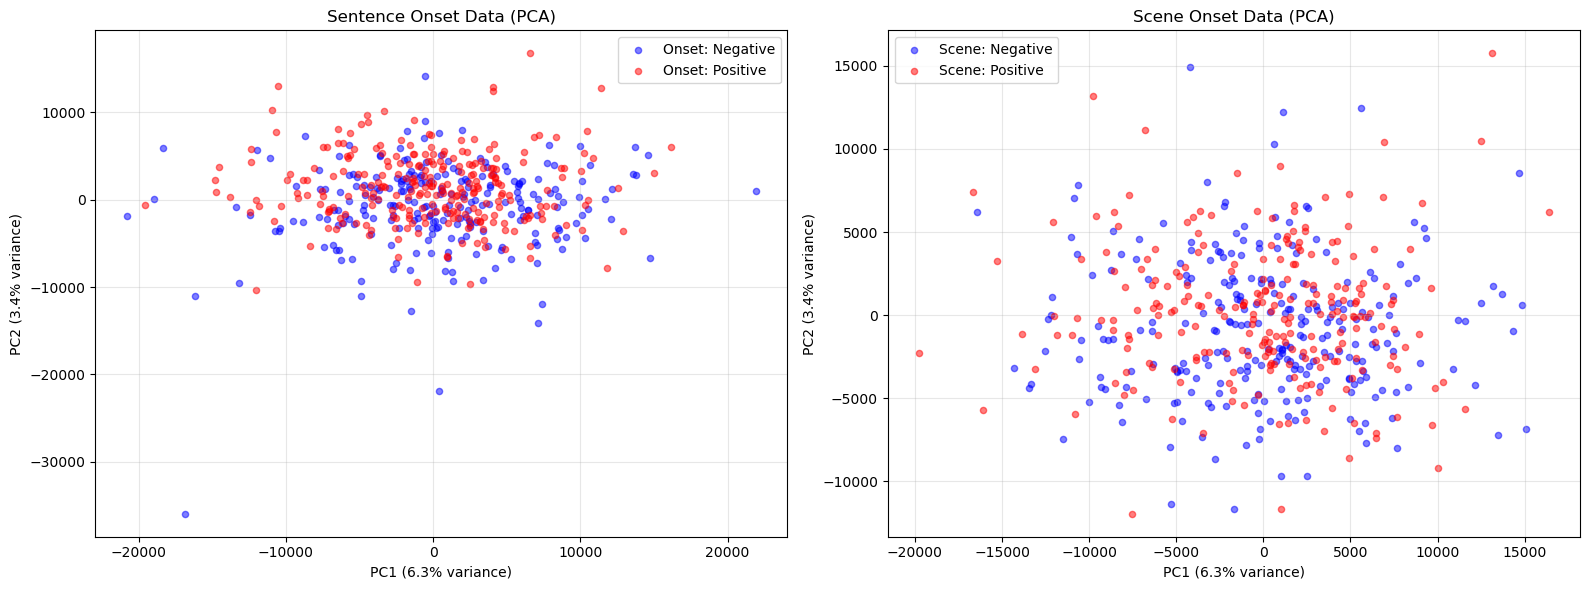

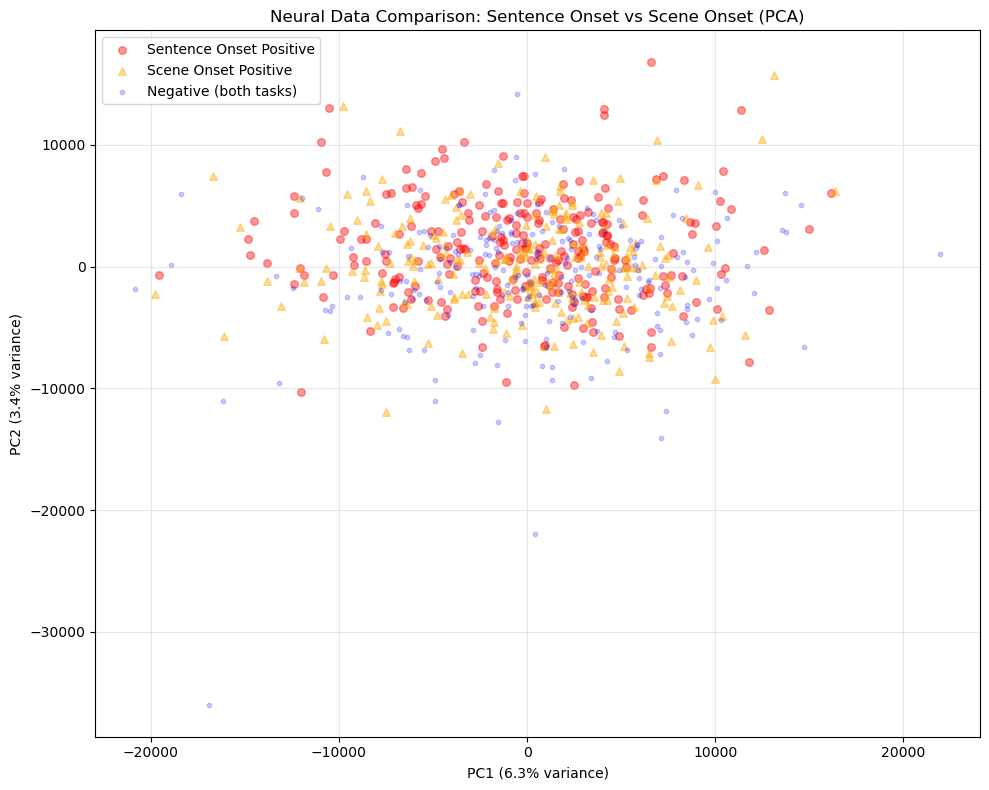

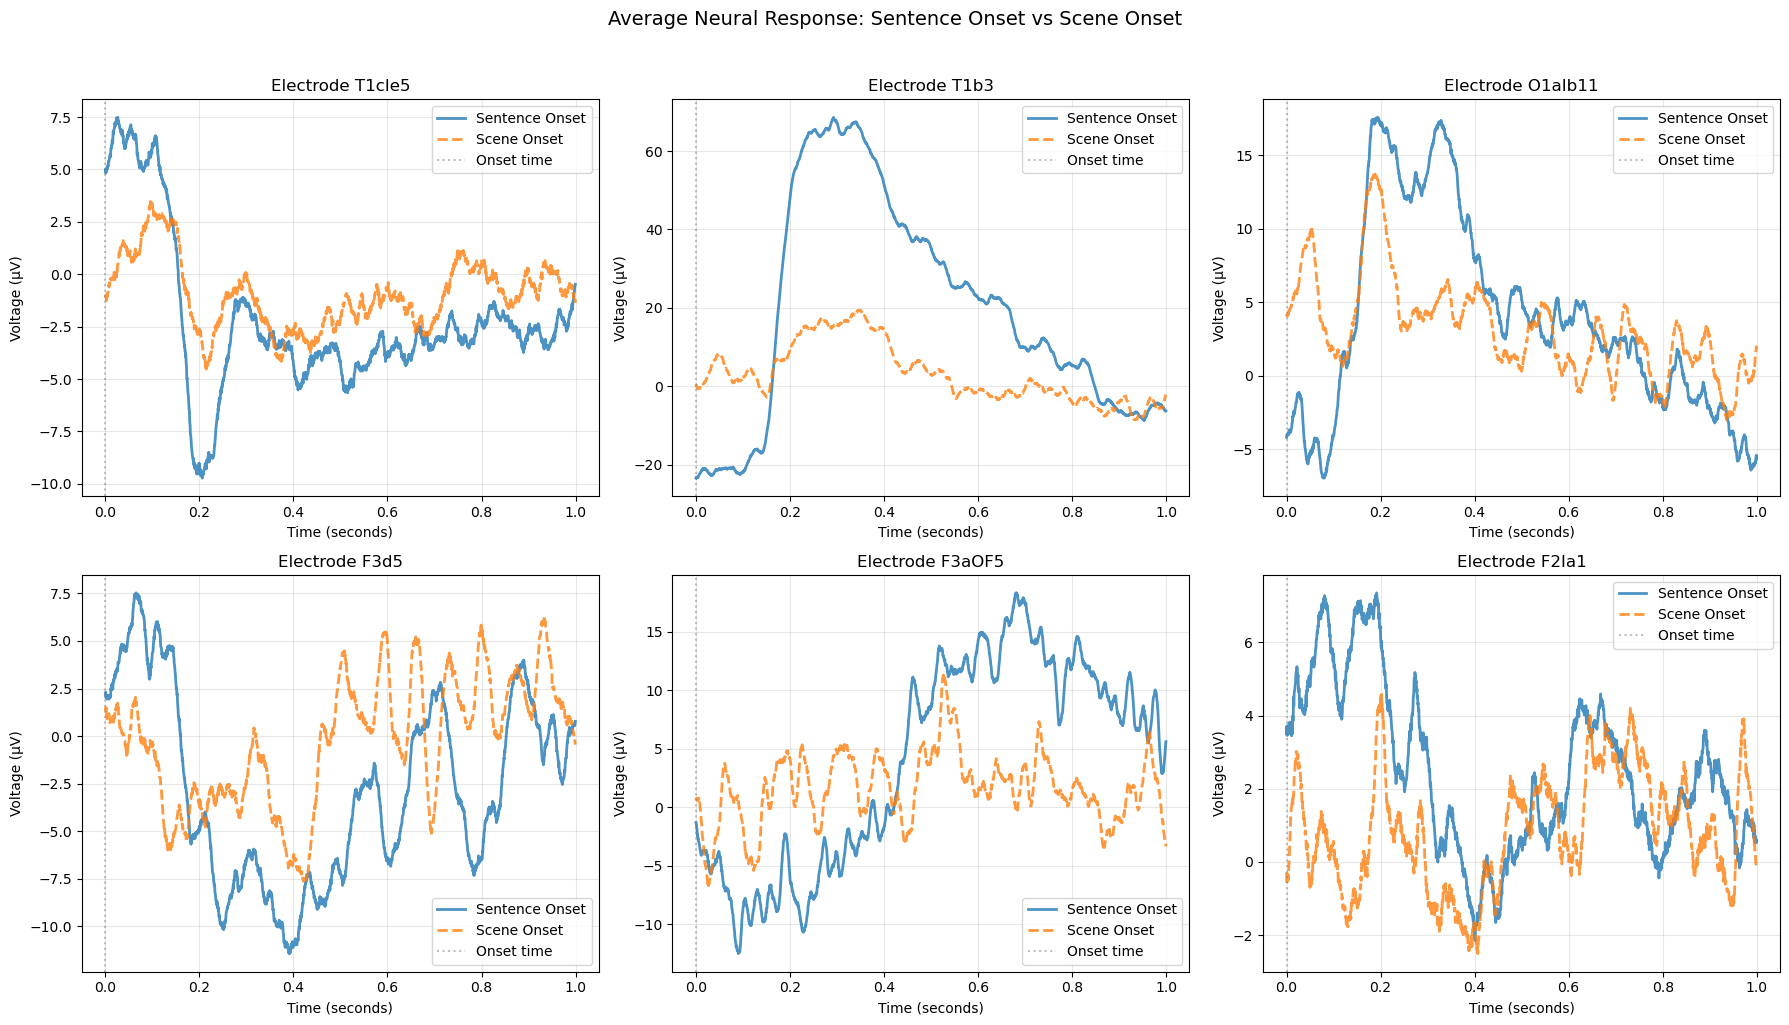

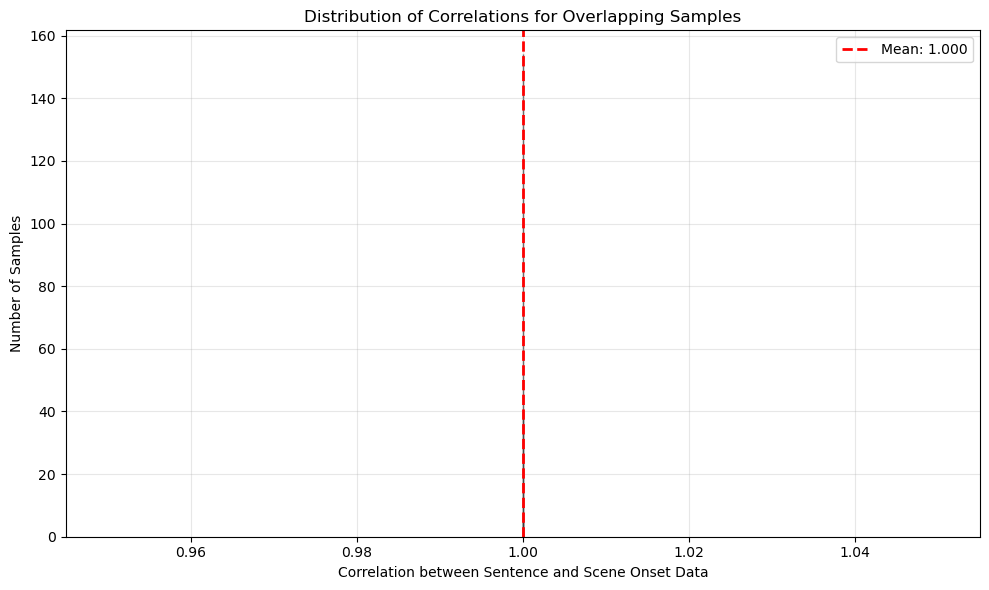


Mean correlation: 1.000 ± 0.000
Min correlation: 1.000
Max correlation: 1.000


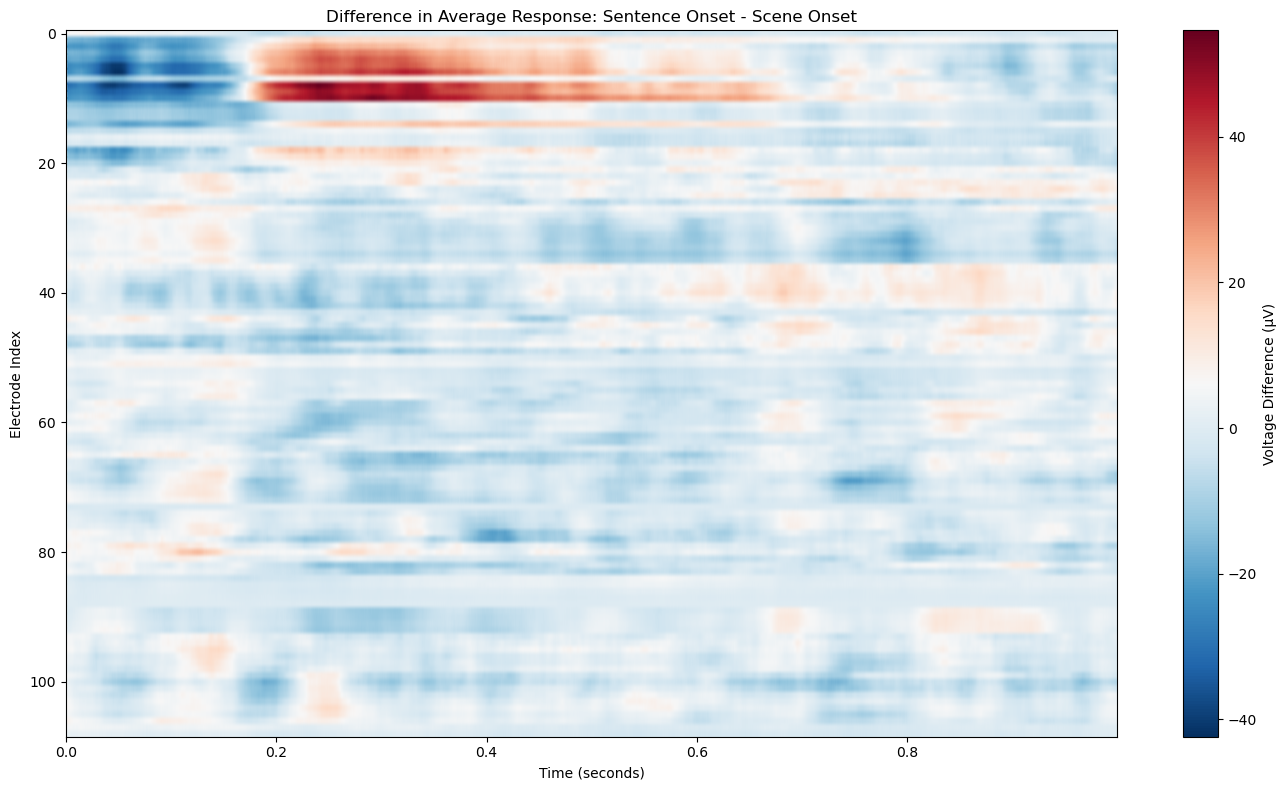

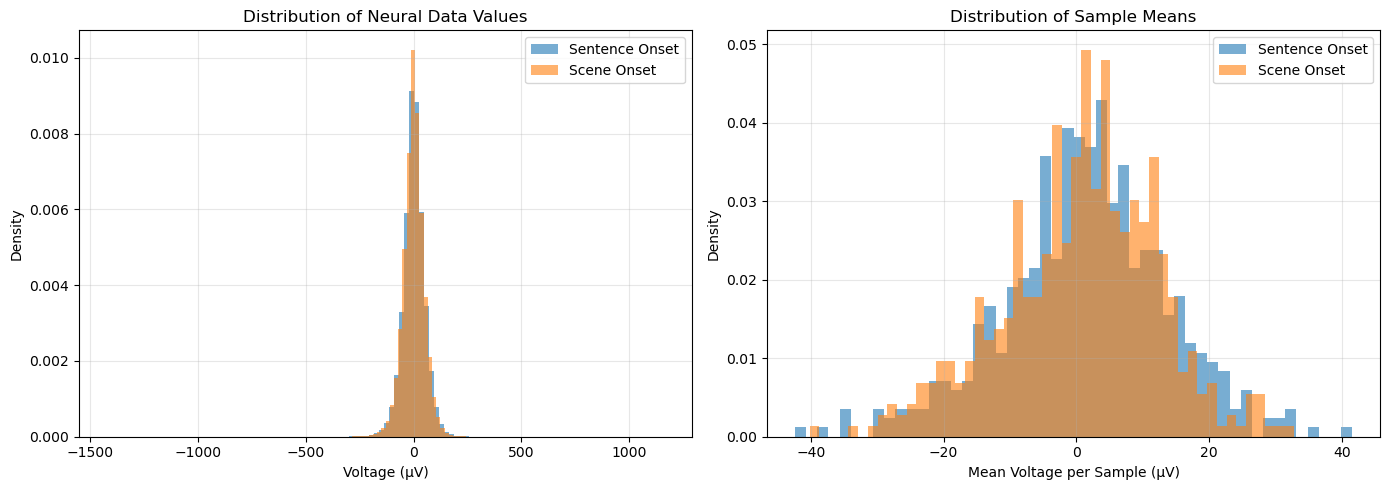


Visualization complete!


In [7]:
## Visualize Neural Data: Scene Onset vs Sentence Onset

from neuroprobe import BrainTreebankSubjectTrialBenchmarkDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns

# Load both datasets
dataset_onset = BrainTreebankSubjectTrialBenchmarkDataset(
    subject, trial_id, dtype=torch.float32, eval_name="onset",
    output_indices=False,
    start_neural_data_before_word_onset=start_neural_data_before_word_onset,
    end_neural_data_after_word_onset=end_neural_data_after_word_onset,
    lite=True, output_dict=False
)

dataset_scene = BrainTreebankSubjectTrialBenchmarkDataset(
    subject, trial_id, dtype=torch.float32, eval_name="scene_onset",
    output_indices=False,
    start_neural_data_before_word_onset=start_neural_data_before_word_onset,
    end_neural_data_after_word_onset=end_neural_data_after_word_onset,
    lite=True, output_dict=False
)

# Sample a subset for visualization (to avoid memory issues)
n_samples = min(500, len(dataset_onset), len(dataset_scene))
sample_indices_onset = np.random.choice(len(dataset_onset), n_samples, replace=False)
sample_indices_scene = np.random.choice(len(dataset_scene), n_samples, replace=False)

# Extract neural data and labels
X_onset = np.array([dataset_onset[i][0].flatten().numpy() for i in sample_indices_onset])
y_onset = np.array([dataset_onset[i][1] for i in sample_indices_onset])

X_scene = np.array([dataset_scene[i][0].flatten().numpy() for i in sample_indices_scene])
y_scene = np.array([dataset_scene[i][1] for i in sample_indices_scene])

print(f"Onset data shape: {X_onset.shape}")
print(f"Scene data shape: {X_scene.shape}")
print(f"Onset labels: {np.bincount(y_onset)}")
print(f"Scene labels: {np.bincount(y_scene)}")

# Plot 1: PCA Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Combine data for PCA
X_combined = np.vstack([X_onset, X_scene])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_combined)

# Split back
X_onset_pca = X_pca[:len(X_onset)]
X_scene_pca = X_pca[len(X_onset):]

# Plot by task
ax = axes[0]
ax.scatter(X_onset_pca[y_onset==0, 0], X_onset_pca[y_onset==0, 1], 
          c='blue', alpha=0.5, label='Onset: Negative', s=20)
ax.scatter(X_onset_pca[y_onset==1, 0], X_onset_pca[y_onset==1, 1], 
          c='red', alpha=0.5, label='Onset: Positive', s=20)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Sentence Onset Data (PCA)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(X_scene_pca[y_scene==0, 0], X_scene_pca[y_scene==0, 1], 
          c='blue', alpha=0.5, label='Scene: Negative', s=20)
ax.scatter(X_scene_pca[y_scene==1, 0], X_scene_pca[y_scene==1, 1], 
          c='red', alpha=0.5, label='Scene: Positive', s=20)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Scene Onset Data (PCA)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('neural_data_pca_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Overlay both tasks in same PCA space
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_onset_pca[y_onset==1, 0], X_onset_pca[y_onset==1, 1], 
          c='red', alpha=0.4, label='Sentence Onset Positive', s=30, marker='o')
ax.scatter(X_scene_pca[y_scene==1, 0], X_scene_pca[y_scene==1, 1], 
          c='orange', alpha=0.4, label='Scene Onset Positive', s=30, marker='^')
ax.scatter(X_onset_pca[y_onset==0, 0], X_onset_pca[y_onset==0, 1], 
          c='blue', alpha=0.2, label='Negative (both tasks)', s=10)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Neural Data Comparison: Sentence Onset vs Scene Onset (PCA)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('neural_data_pca_overlay.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 3: Average neural response per electrode
n_electrodes = dataset_onset[0][0].shape[0]
n_time_samples = dataset_onset[0][0].shape[1]

# Calculate mean response for positive samples
onset_positive_mean = X_onset[y_onset==1].reshape(-1, n_electrodes, n_time_samples).mean(axis=0)
scene_positive_mean = X_scene[y_scene==1].reshape(-1, n_electrodes, n_time_samples).mean(axis=0)

# Plot average response for a few example electrodes
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
electrode_indices = [0, 10, 20, 30, 40, 50]  # Sample electrodes

time_axis = np.arange(n_time_samples) / neuroprobe_config.SAMPLING_RATE

for idx, ax in enumerate(axes.flat):
    if idx < len(electrode_indices):
        elec_idx = electrode_indices[idx]
        electrode_label = dataset_onset.electrode_labels[elec_idx]
        
        ax.plot(time_axis, onset_positive_mean[elec_idx], 
               label='Sentence Onset', linewidth=2, alpha=0.8)
        ax.plot(time_axis, scene_positive_mean[elec_idx], 
               label='Scene Onset', linewidth=2, alpha=0.8, linestyle='--')
        ax.axvline(x=0, color='gray', linestyle=':', alpha=0.5, label='Onset time')
        ax.set_xlabel('Time (seconds)')
        ax.set_ylabel('Voltage (μV)')
        ax.set_title(f'Electrode {electrode_label}')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.suptitle('Average Neural Response: Sentence Onset vs Scene Onset', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('neural_data_average_response.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 4: Correlation between tasks
# For overlapping samples, check correlation
if len(overlapping_indices) > 0:
    # Get overlapping samples
    onset_idx_to_pos = {idx: i for i, idx in enumerate(onset_indices)}
    scene_idx_to_pos = {idx: i for i, idx in enumerate(scene_indices)}
    
    overlapping_list = list(overlapping_indices)[:min(200, len(overlapping_indices))]
    
    X_onset_overlap = []
    X_scene_overlap = []
    
    for idx in overlapping_list:
        onset_pos = onset_idx_to_pos[idx]
        scene_pos = scene_idx_to_pos[idx]
        X_onset_overlap.append(dataset_onset[onset_pos][0].flatten().numpy())
        X_scene_overlap.append(dataset_scene[scene_pos][0].flatten().numpy())
    
    X_onset_overlap = np.array(X_onset_overlap)
    X_scene_overlap = np.array(X_scene_overlap)
    
    # Calculate correlation for each sample
    correlations = [np.corrcoef(X_onset_overlap[i], X_scene_overlap[i])[0,1] 
                   for i in range(len(X_onset_overlap))]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(correlations, bins=50, alpha=0.7, edgecolor='black')
    ax.axvline(x=np.mean(correlations), color='red', linestyle='--', 
              linewidth=2, label=f'Mean: {np.mean(correlations):.3f}')
    ax.set_xlabel('Correlation between Sentence and Scene Onset Data')
    ax.set_ylabel('Number of Samples')
    ax.set_title('Distribution of Correlations for Overlapping Samples')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('neural_data_correlation_distribution.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nMean correlation: {np.mean(correlations):.3f} ± {np.std(correlations):.3f}")
    print(f"Min correlation: {np.min(correlations):.3f}")
    print(f"Max correlation: {np.max(correlations):.3f}")

# Plot 5: Heatmap of average difference
mean_diff = onset_positive_mean - scene_positive_mean

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(mean_diff, aspect='auto', cmap='RdBu_r', 
               extent=[time_axis[0], time_axis[-1], n_electrodes-0.5, -0.5])
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Electrode Index')
ax.set_title('Difference in Average Response: Sentence Onset - Scene Onset')
ax.axvline(x=0, color='white', linestyle='--', linewidth=1, alpha=0.7)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Voltage Difference (μV)')
plt.tight_layout()
plt.savefig('neural_data_difference_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 6: Distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Flatten all data
onset_flat = X_onset.flatten()
scene_flat = X_scene.flatten()

ax = axes[0]
ax.hist(onset_flat, bins=100, alpha=0.6, label='Sentence Onset', density=True)
ax.hist(scene_flat, bins=100, alpha=0.6, label='Scene Onset', density=True)
ax.set_xlabel('Voltage (μV)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Neural Data Values')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
# Compare means per sample
onset_means = X_onset.mean(axis=1)
scene_means = X_scene.mean(axis=1)
ax.hist(onset_means, bins=50, alpha=0.6, label='Sentence Onset', density=True)
ax.hist(scene_means, bins=50, alpha=0.6, label='Scene Onset', density=True)
ax.set_xlabel('Mean Voltage per Sample (μV)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Sample Means')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('neural_data_distribution_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization complete!")

In [8]:

BRAINTREEBANK_SUBJECT_TRIAL_MOVIE_NAME_MAPPING = { # btbankX_Y means subject_id=X, trial_id=Y.
    "btbank1_0": "fantastic-mr-fox",
    "btbank1_1": "the-martian",
    "btbank1_2": "thor-ragnarok",
    "btbank2_0": "venom",
    "btbank2_1": "spider-man-3-homecoming",
    "btbank2_2": "guardians-of-the-galaxy",
    "btbank2_3": "guardians-of-the-galaxy-2",
    "btbank2_4": "avengers-infinity-war",
    "btbank2_5": "black-panther",
    "btbank2_6": "aquaman",
    "btbank3_0": "cars-2",
    "btbank3_1": "lotr-1",
    "btbank3_2": "lotr-2",
    "btbank4_0": "shrek-the-third",
    "btbank4_1": "megamind",
    "btbank4_2": "incredibles",
    "btbank5_0": "fantastic-mr-fox",
    "btbank6_0": "megamind",
    "btbank6_1": "toy-story",
    "btbank6_4": "coraline",
    "btbank7_0": "cars-2",
    "btbank7_1": "megamind",
    "btbank8_0": "sesame-street-episode-3990",
    "btbank9_0": "ant-man",
    "btbank10_0": "cars-2",
    "btbank10_1": "spider-man-far-from-home"
}
movie_name = BRAINTREEBANK_SUBJECT_TRIAL_MOVIE_NAME_MAPPING[f"{subject.subject_identifier}_{trial_id}"]

Found 510 scene boundaries
First 10 scene boundaries (seconds): [4, 5, 13, 17, 26, 30, 31, 32, 33, 34]

Found 2044 sentence onsets
First 10 sentence onset times (seconds): [47.15       48.87       52.9        57.99361022 59.85       64.8
 66.23       68.54888179 69.45693291 70.82747604]

Window around each word: [47.15, 48.15] seconds
  (window extends 0.00s before and 1.00s after each word)
  Sentence onset at 113.84s: scene boundary at [114] (within window)
  Sentence onset at 116.20s: scene boundary at [117] (within window)
  Sentence onset at 138.33s: scene boundary at [139] (within window)
  Sentence onset at 145.92s: scene boundary at [146] (within window)
  Sentence onset at 146.98s: scene boundary at [147] (within window)
  Sentence onset at 222.16s: scene boundary at [223] (within window)
  Sentence onset at 225.87s: scene boundary at [226] (within window)
  Sentence onset at 229.60s: scene boundary at [230] (within window)
  Sentence onset at 235.37s: scene boundary at [236] 

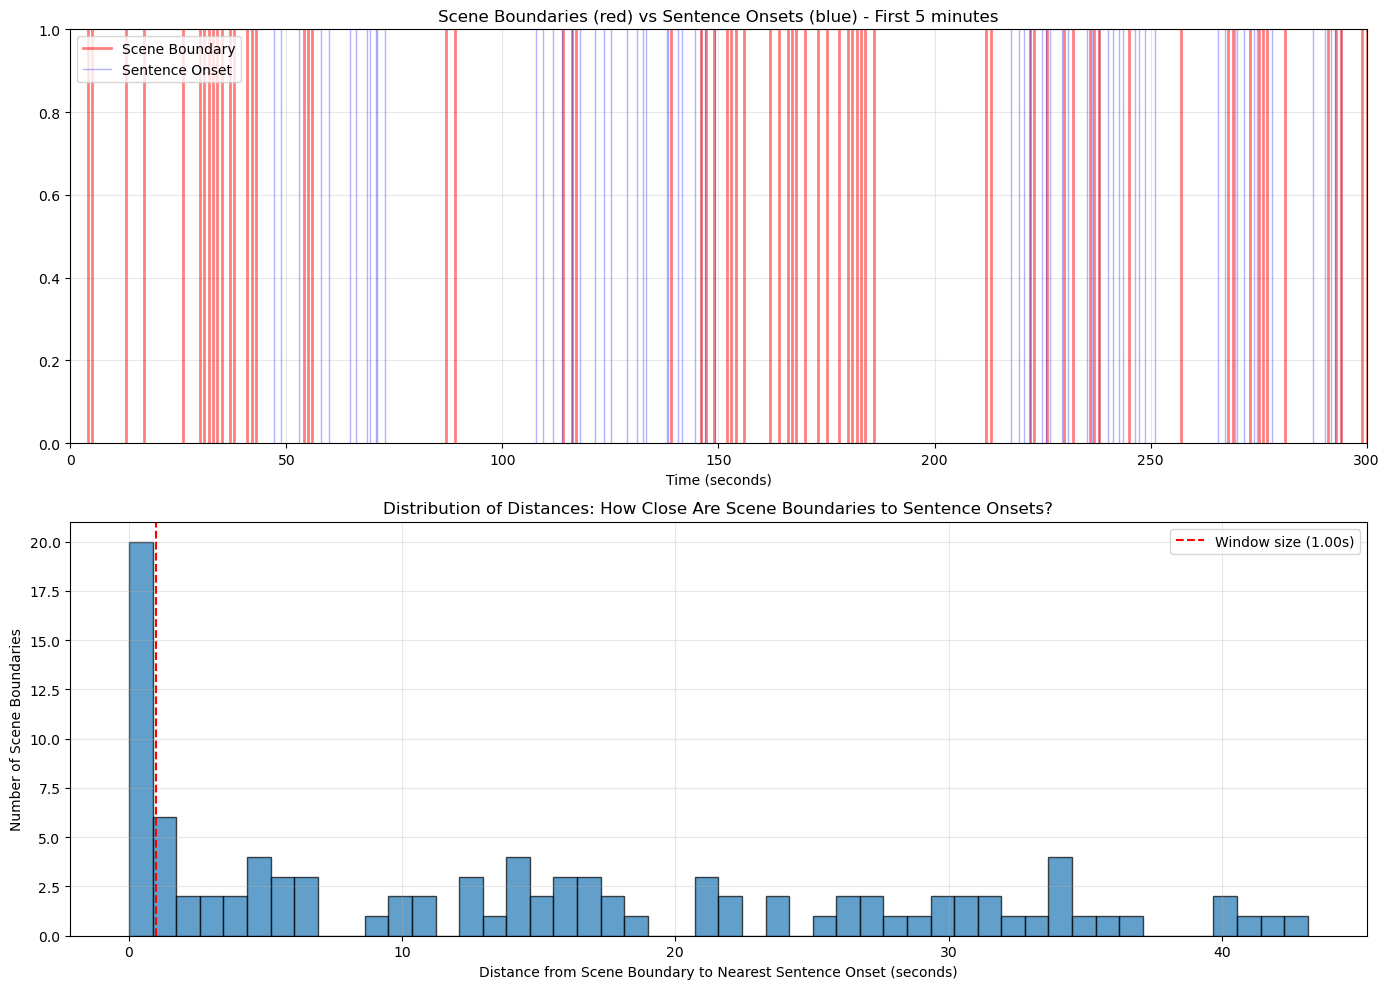


CONCLUSION:
✓ Scene boundaries and sentence onsets are more independent.


In [9]:
## Investigate Why Scene Switches Align with Sentence Onsets

from neuroprobe import BrainTreebankSubjectTrialBenchmarkDataset
import numpy as np
import pandas as pd
import json
import os

# Load the scene annotations to see when scene changes actually occur
scene_annotations_path = os.path.join(neuroprobe_config.ROOT_DIR, 'scene_annotations', 'scene_annotations.json')
with open(scene_annotations_path, 'r') as f:
    scene_annotations_data = json.load(f)

annotations_dict = scene_annotations_data[0]

# Find the movie key (same logic as in datasets.py)
movie_key = None
for key in annotations_dict.keys():
    if f':{movie_name}:' in key or key.endswith(f':{movie_name}'):
        if 'all-annotations' in key:
            movie_key = key
            break
        elif movie_key is None:
            movie_key = key

if movie_key:
    movie_annotations = annotations_dict[movie_key]
    
    # Parse scene boundaries
    scene_labels_dict = {}
    for json_key_str, start_time_str in movie_annotations.items():
        try:
            annotation = json.loads(json_key_str)
            start_time = int(round(float(annotation.get('startTime', start_time_str))))
            label = annotation.get('label', '')
            scene_labels_dict[start_time] = label
        except:
            continue
    
    # Find scene boundaries
    scene_times = sorted(scene_labels_dict.keys())
    scene_boundaries = []
    for i in range(1, len(scene_times)):
        prev_time = scene_times[i-1]
        curr_time = scene_times[i]
        prev_label = scene_labels_dict[prev_time]
        curr_label = scene_labels_dict[curr_time]
        if prev_label != curr_label:
            scene_boundaries.append(curr_time)
    
    print(f"Found {len(scene_boundaries)} scene boundaries")
    print(f"First 10 scene boundaries (seconds): {scene_boundaries[:10]}")
    
    # Now check which words are sentence onsets
    dataset_onset = BrainTreebankSubjectTrialBenchmarkDataset(
        subject, trial_id, dtype=torch.float32, eval_name="onset",
        output_indices=False,
        start_neural_data_before_word_onset=start_neural_data_before_word_onset,
        end_neural_data_after_word_onset=end_neural_data_after_word_onset,
        lite=True, output_dict=False
    )
    
    # Get word times and which are sentence onsets
    words_df = dataset_onset.all_words_df  # Access the internal dataframe
    word_times = words_df['start'].values
    is_sentence_onset = words_df['is_onset'].values == 1
    
    sentence_onset_times = word_times[is_sentence_onset]
    
    print(f"\nFound {len(sentence_onset_times)} sentence onsets")
    print(f"First 10 sentence onset times (seconds): {sentence_onset_times[:10]}")
    
    # Check how close scene boundaries are to sentence onsets
    window_start_seconds = start_neural_data_before_word_onset / neuroprobe_config.SAMPLING_RATE
    window_end_seconds = end_neural_data_after_word_onset / neuroprobe_config.SAMPLING_RATE
    
    print(f"\nWindow around each word: [{word_times[0] - window_start_seconds:.2f}, {word_times[0] + window_end_seconds:.2f}] seconds")
    print(f"  (window extends {window_start_seconds:.2f}s before and {window_end_seconds:.2f}s after each word)")
    
    # For each sentence onset, check if a scene boundary is nearby
    scene_near_sentence_onset = []
    for sent_time in sentence_onset_times[:50]:  # Check first 50
        window_start = sent_time - window_start_seconds
        window_end = sent_time + window_end_seconds
        
        # Check if any scene boundary is in this window
        nearby_scenes = [sb for sb in scene_boundaries if window_start <= sb <= window_end]
        scene_near_sentence_onset.append(len(nearby_scenes) > 0)
        
        if len(nearby_scenes) > 0:
            print(f"  Sentence onset at {sent_time:.2f}s: scene boundary at {nearby_scenes} (within window)")
    
    print(f"\nOf first 50 sentence onsets, {sum(scene_near_sentence_onset)} have scene boundaries in their window")
    print(f"Percentage: {sum(scene_near_sentence_onset)/len(scene_near_sentence_onset)*100:.1f}%")
    
    # Also check the reverse: for each scene boundary, is there a sentence onset nearby?
    sentence_near_scene_boundary = []
    for scene_time in scene_boundaries[:50]:  # Check first 50
        # Check if any sentence onset is within the window around this scene boundary
        nearby_sentences = [st for st in sentence_onset_times 
                           if (st - window_start_seconds) <= scene_time <= (st + window_end_seconds)]
        sentence_near_scene_boundary.append(len(nearby_sentences) > 0)
        
        if len(nearby_sentences) > 0:
            print(f"  Scene boundary at {scene_time:.2f}s: sentence onset at {nearby_sentences} (within window)")
    
    print(f"\nOf first 50 scene boundaries, {sum(sentence_near_scene_boundary)} have sentence onsets in their window")
    print(f"Percentage: {sum(sentence_near_scene_boundary)/len(sentence_near_scene_boundary)*100:.1f}%")
    
    # Plot the alignment
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot 1: Timeline showing scene boundaries and sentence onsets
    ax = axes[0]
    time_range = (0, min(300, max(max(scene_boundaries), max(sentence_onset_times))))
    
    # Plot scene boundaries
    for sb in scene_boundaries:
        if sb <= time_range[1]:
            ax.axvline(x=sb, color='red', alpha=0.5, linewidth=2, label='Scene Boundary' if sb == scene_boundaries[0] else '')
    
    # Plot sentence onsets
    for st in sentence_onset_times:
        if st <= time_range[1]:
            ax.axvline(x=st, color='blue', alpha=0.3, linewidth=1, label='Sentence Onset' if st == sentence_onset_times[0] else '')
    
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('')
    ax.set_title('Scene Boundaries (red) vs Sentence Onsets (blue) - First 5 minutes')
    ax.set_xlim(time_range)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Histogram of distances between scene boundaries and nearest sentence onsets
    ax = axes[1]
    distances = []
    for sb in scene_boundaries[:100]:  # Check first 100
        # Find nearest sentence onset
        nearest_sent = sentence_onset_times[np.argmin(np.abs(sentence_onset_times - sb))]
        distance = abs(nearest_sent - sb)
        distances.append(distance)
    
    ax.hist(distances, bins=50, alpha=0.7, edgecolor='black')
    ax.axvline(x=window_start_seconds + window_end_seconds, color='red', linestyle='--', 
              label=f'Window size ({window_start_seconds + window_end_seconds:.2f}s)')
    ax.set_xlabel('Distance from Scene Boundary to Nearest Sentence Onset (seconds)')
    ax.set_ylabel('Number of Scene Boundaries')
    ax.set_title('Distribution of Distances: How Close Are Scene Boundaries to Sentence Onsets?')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('scene_sentence_alignment_analysis.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n{'='*60}")
    print("CONCLUSION:")
    print(f"{'='*60}")
    if sum(scene_near_sentence_onset)/len(scene_near_sentence_onset) > 0.8:
        print("⚠️  Most sentence onsets have scene boundaries in their windows!")
        print("   This explains why scene_onset and sentence onset align.")
        print("   Possible reasons:")
        print("   1. Scene changes in movies often occur at sentence boundaries")
        print("   2. The window is large enough to capture both events")
        print("   3. The scene annotations might be aligned to sentence boundaries")
    else:
        print("✓ Scene boundaries and sentence onsets are more independent.")
else:
    print(f"Could not find scene annotations for movie: {subject.movie_name}")

Total scene boundaries found: 510
Scene boundaries (first 20): [4, 5, 13, 17, 26, 30, 31, 32, 33, 34, 35, 37, 38, 41, 42, 43, 54, 55, 56, 87]

Total sentence onsets found: 2044
Sentence onsets (first 20): [ 47.15        48.87        52.9         57.99361022  59.85
  64.8         66.23        68.54888179  69.45693291  70.82747604
  71.08        72.94       107.67       109.43       111.77111821
 113.84       116.20095847 117.86627157 121.37       123.47923323]

Window around each word: [0.00s before, 1.00s after]
Total window size: 1.00 seconds

RESULTS: Scene Boundary → Sentence Onset
Scene boundaries with sentence onset in window: 159/510 (31.2%)
Scene boundaries WITHOUT sentence onset: 351/510 (68.8%)

✓ Scene boundaries and sentence onsets are more independent.

First 20 scene boundaries and their matches:
  Scene at 4.00s → NO sentence onset in window (nearest: 47.15s, 43.15s away)
  Scene at 5.00s → NO sentence onset in window (nearest: 47.15s, 42.15s away)
  Scene at 13.00s → NO 

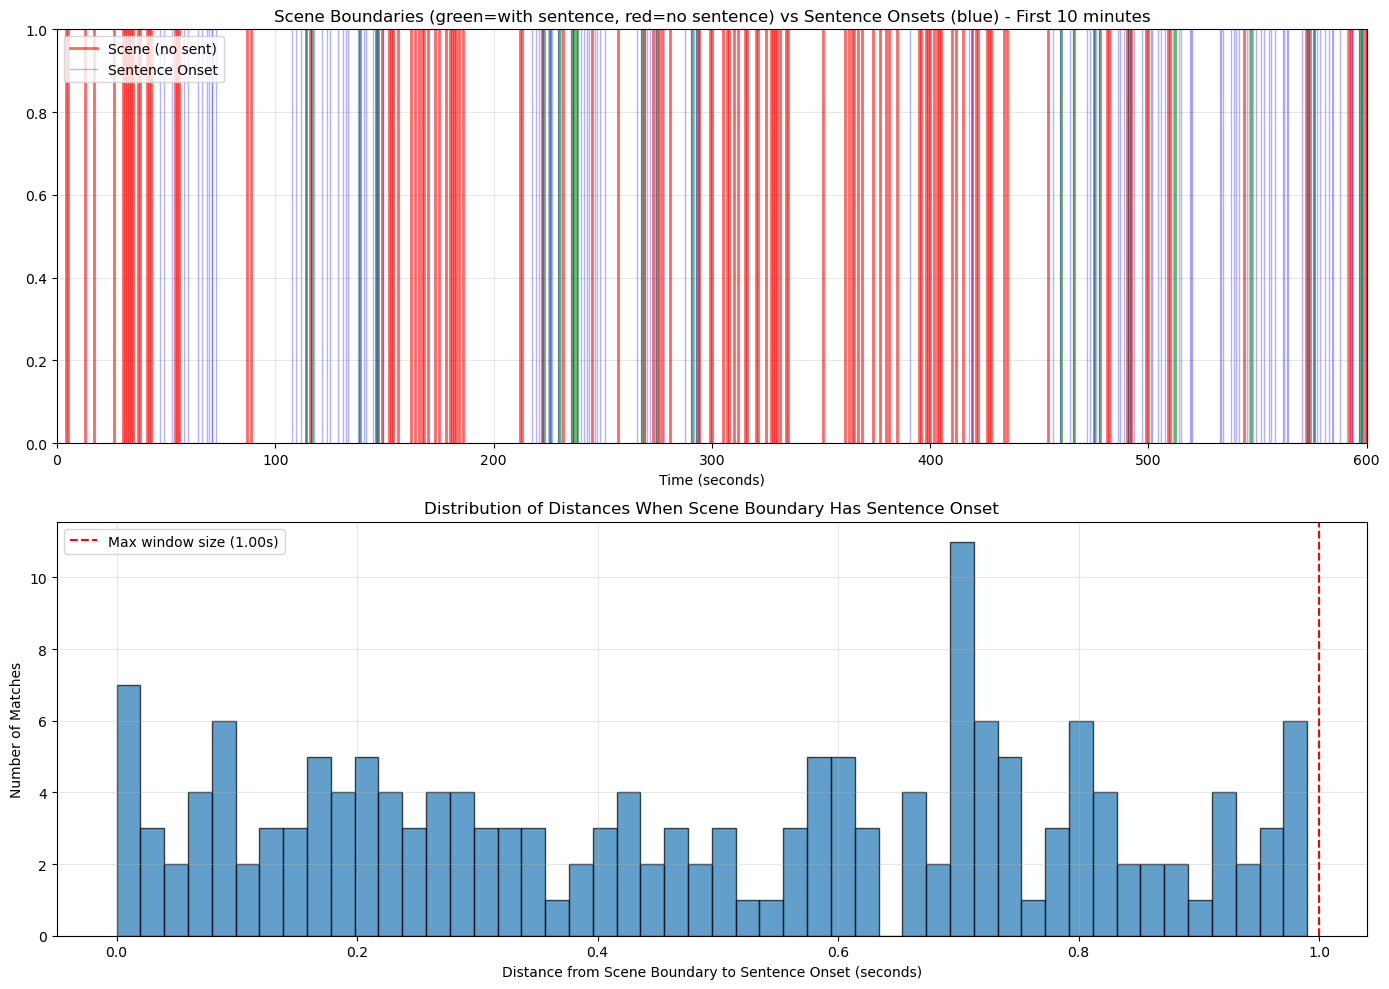


SUMMARY
Scene boundaries → Sentence onsets: 31.2% match
Sentence onsets → Scene boundaries: 21.0% match


In [10]:
## Check: Does Every Scene Boundary Have a Sentence Onset?

from neuroprobe import BrainTreebankSubjectTrialBenchmarkDataset
import numpy as np
import pandas as pd
import json
import os
import matplotlib.pyplot as plt

# Load scene annotations
scene_annotations_path = os.path.join(neuroprobe_config.ROOT_DIR, 'scene_annotations', 'scene_annotations.json')
with open(scene_annotations_path, 'r') as f:
    scene_annotations_data = json.load(f)

annotations_dict = scene_annotations_data[0]

# Find the movie key
movie_key = None
for key in annotations_dict.keys():
    if f':{movie_name}:' in key or key.endswith(f':{movie_name}'):
        if 'all-annotations' in key:
            movie_key = key
            break
        elif movie_key is None:
            movie_key = key

if movie_key:
    movie_annotations = annotations_dict[movie_key]
    
    # Parse scene boundaries
    scene_labels_dict = {}
    for json_key_str, start_time_str in movie_annotations.items():
        try:
            annotation = json.loads(json_key_str)
            start_time = int(round(float(annotation.get('startTime', start_time_str))))
            label = annotation.get('label', '')
            scene_labels_dict[start_time] = label
        except:
            continue
    
    # Find scene boundaries (where label changes)
    scene_times = sorted(scene_labels_dict.keys())
    scene_boundaries = []
    for i in range(1, len(scene_times)):
        prev_time = scene_times[i-1]
        curr_time = scene_times[i]
        prev_label = scene_labels_dict[prev_time]
        curr_label = scene_labels_dict[curr_time]
        if prev_label != curr_label:
            scene_boundaries.append(curr_time)
    
    scene_boundaries = sorted(list(set(scene_boundaries)))
    
    print(f"Total scene boundaries found: {len(scene_boundaries)}")
    print(f"Scene boundaries (first 20): {scene_boundaries[:20]}")
    
    # Get sentence onset times
    dataset_onset = BrainTreebankSubjectTrialBenchmarkDataset(
        subject, trial_id, dtype=torch.float32, eval_name="onset",
        output_indices=False,
        start_neural_data_before_word_onset=start_neural_data_before_word_onset,
        end_neural_data_after_word_onset=end_neural_data_after_word_onset,
        lite=True, output_dict=False
    )
    
    # Access the words dataframe to get sentence onsets
    words_df = dataset_onset.all_words_df
    word_times = words_df['start'].values
    is_sentence_onset = words_df['is_onset'].values == 1
    
    sentence_onset_times = word_times[is_sentence_onset]
    
    print(f"\nTotal sentence onsets found: {len(sentence_onset_times)}")
    print(f"Sentence onsets (first 20): {sentence_onset_times[:20]}")
    
    # Window parameters (same as used in scene_onset detection)
    window_start_seconds = start_neural_data_before_word_onset / neuroprobe_config.SAMPLING_RATE
    window_end_seconds = end_neural_data_after_word_onset / neuroprobe_config.SAMPLING_RATE
    
    print(f"\nWindow around each word: [{window_start_seconds:.2f}s before, {window_end_seconds:.2f}s after]")
    print(f"Total window size: {window_start_seconds + window_end_seconds:.2f} seconds")
    
    # For EACH scene boundary, check if there's a sentence onset within the window
    # (This is the reverse check - scene boundary -> sentence onset)
    scene_boundary_has_sentence_onset = []
    distances = []
    matching_sentence_times = []
    
    for scene_time in scene_boundaries:
        # Check if any sentence onset is within the window around this scene boundary
        # The window is: [word_time - window_start, word_time + window_end]
        # So for a scene boundary at time T, we need a sentence onset at time S where:
        # S - window_start <= T <= S + window_end
        # Which means: T - window_end <= S <= T + window_start
        
        # Find sentence onsets within the window
        nearby_sentences = []
        for sent_time in sentence_onset_times:
            window_start = sent_time - window_start_seconds
            window_end = sent_time + window_end_seconds
            if window_start <= scene_time <= window_end:
                nearby_sentences.append(sent_time)
                distances.append(abs(sent_time - scene_time))
        
        has_match = len(nearby_sentences) > 0
        scene_boundary_has_sentence_onset.append(has_match)
        
        if has_match:
            matching_sentence_times.append((scene_time, nearby_sentences[0]))
    
    n_matches = sum(scene_boundary_has_sentence_onset)
    n_total = len(scene_boundary_has_sentence_onset)
    match_percentage = (n_matches / n_total * 100) if n_total > 0 else 0
    
    print(f"\n{'='*60}")
    print("RESULTS: Scene Boundary → Sentence Onset")
    print(f"{'='*60}")
    print(f"Scene boundaries with sentence onset in window: {n_matches}/{n_total} ({match_percentage:.1f}%)")
    print(f"Scene boundaries WITHOUT sentence onset: {n_total - n_matches}/{n_total} ({100-match_percentage:.1f}%)")
    
    if match_percentage > 90:
        print("\n⚠️  WARNING: Almost ALL scene boundaries have sentence onsets nearby!")
        print("   This means scene_onset and sentence onset are essentially the same task.")
    elif match_percentage > 50:
        print("\n⚠️  Many scene boundaries align with sentence onsets.")
        print("   The tasks will be highly correlated.")
    else:
        print("\n✓ Scene boundaries and sentence onsets are more independent.")
    
    # Show examples
    print(f"\nFirst 20 scene boundaries and their matches:")
    for i, (scene_time, has_match) in enumerate(zip(scene_boundaries[:20], scene_boundary_has_sentence_onset[:20])):
        if has_match:
            sent_time = matching_sentence_times[i][1] if i < len(matching_sentence_times) else "?"
            print(f"  Scene at {scene_time:.2f}s → Sentence onset at {sent_time:.2f}s (distance: {abs(scene_time - sent_time):.2f}s)")
        else:
            # Find nearest sentence onset
            nearest_sent = sentence_onset_times[np.argmin(np.abs(sentence_onset_times - scene_time))]
            distance = abs(nearest_sent - scene_time)
            print(f"  Scene at {scene_time:.2f}s → NO sentence onset in window (nearest: {nearest_sent:.2f}s, {distance:.2f}s away)")
    
    # Also check the reverse: sentence onset → scene boundary
    print(f"\n{'='*60}")
    print("REVERSE CHECK: Sentence Onset → Scene Boundary")
    print(f"{'='*60}")
    
    sentence_onset_has_scene_boundary = []
    for sent_time in sentence_onset_times[:100]:  # Check first 100
        window_start = sent_time - window_start_seconds
        window_end = sent_time + window_end_seconds
        
        # Check if any scene boundary is in this window
        nearby_scenes = [sb for sb in scene_boundaries if window_start <= sb <= window_end]
        sentence_onset_has_scene_boundary.append(len(nearby_scenes) > 0)
    
    n_reverse_matches = sum(sentence_onset_has_scene_boundary)
    n_reverse_total = len(sentence_onset_has_scene_boundary)
    reverse_match_percentage = (n_reverse_matches / n_reverse_total * 100) if n_reverse_total > 0 else 0
    
    print(f"Sentence onsets with scene boundary in window: {n_reverse_matches}/{n_reverse_total} ({reverse_match_percentage:.1f}%)")
    
    # Visualize
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot 1: Timeline
    ax = axes[0]
    time_range = (0, min(600, max(max(scene_boundaries), max(sentence_onset_times)) if len(scene_boundaries) > 0 and len(sentence_onset_times) > 0 else 300))
    
    # Plot scene boundaries
    for i, sb in enumerate(scene_boundaries):
        if sb <= time_range[1]:
            color = 'green' if scene_boundary_has_sentence_onset[i] else 'red'
            ax.axvline(x=sb, color=color, alpha=0.6, linewidth=2, 
                      label='Scene (with sent)' if i == 0 and color == 'green' else 
                            'Scene (no sent)' if i == 0 and color == 'red' else '')
    
    # Plot sentence onsets
    for st in sentence_onset_times:
        if st <= time_range[1]:
            ax.axvline(x=st, color='blue', alpha=0.3, linewidth=1, 
                      label='Sentence Onset' if st == sentence_onset_times[0] else '')
    
    ax.set_xlabel('Time (seconds)')
    ax.set_title(f'Scene Boundaries (green=with sentence, red=no sentence) vs Sentence Onsets (blue) - First 10 minutes')
    ax.set_xlim(time_range)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Distance distribution
    ax = axes[1]
    if len(distances) > 0:
        ax.hist(distances, bins=50, alpha=0.7, edgecolor='black')
        ax.axvline(x=window_start_seconds + window_end_seconds, color='red', linestyle='--', 
                  label=f'Max window size ({window_start_seconds + window_end_seconds:.2f}s)')
        ax.set_xlabel('Distance from Scene Boundary to Sentence Onset (seconds)')
        ax.set_ylabel('Number of Matches')
        ax.set_title('Distribution of Distances When Scene Boundary Has Sentence Onset')
        ax.legend()
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No matches found', ha='center', va='center', transform=ax.transAxes)
    
    plt.tight_layout()
    plt.savefig('scene_boundary_sentence_onset_alignment.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n{'='*60}")
    print("SUMMARY")
    print(f"{'='*60}")
    print(f"Scene boundaries → Sentence onsets: {match_percentage:.1f}% match")
    print(f"Sentence onsets → Scene boundaries: {reverse_match_percentage:.1f}% match")
    
    if match_percentage > 90 and reverse_match_percentage > 90:
        print("\n🚨 CRITICAL: The tasks are essentially identical!")
        print("   You cannot distinguish electrode importance between them.")
    elif match_percentage > 70 or reverse_match_percentage > 70:
        print("\n⚠️  The tasks are highly correlated.")
        print("   Consider using alternative approaches to distinguish them.")
else:
    print(f"Could not find scene annotations for movie: {movie_name}")

Extracting electrode importance for Sentence Onset...
  Fold 1: Trained onset classifier
  Fold 2: Trained onset classifier

Extracting electrode importance for Scene Onset...
  Fold 1: Trained scene_onset classifier
  Fold 2: Trained scene_onset classifier

Top 10 electrodes for SENTENCE ONSET (sorted by importance):
   electrode  sentence_onset_importance  scene_onset_importance
8       T1b1                   0.004016                0.002511
18    O1aIb9                   0.003484                0.002271
48      F3c5                   0.003404                0.002062
14    T1aIc3                   0.003396                0.001954
9       T1b2                   0.003276                0.001897
46      F3c3                   0.002875                0.001935
7    T1cIe12                   0.002494                0.001924
19   O1aIb10                   0.002457                0.002656
10      T1b3                   0.002368                0.001979
11      T1b4                   0.002367 

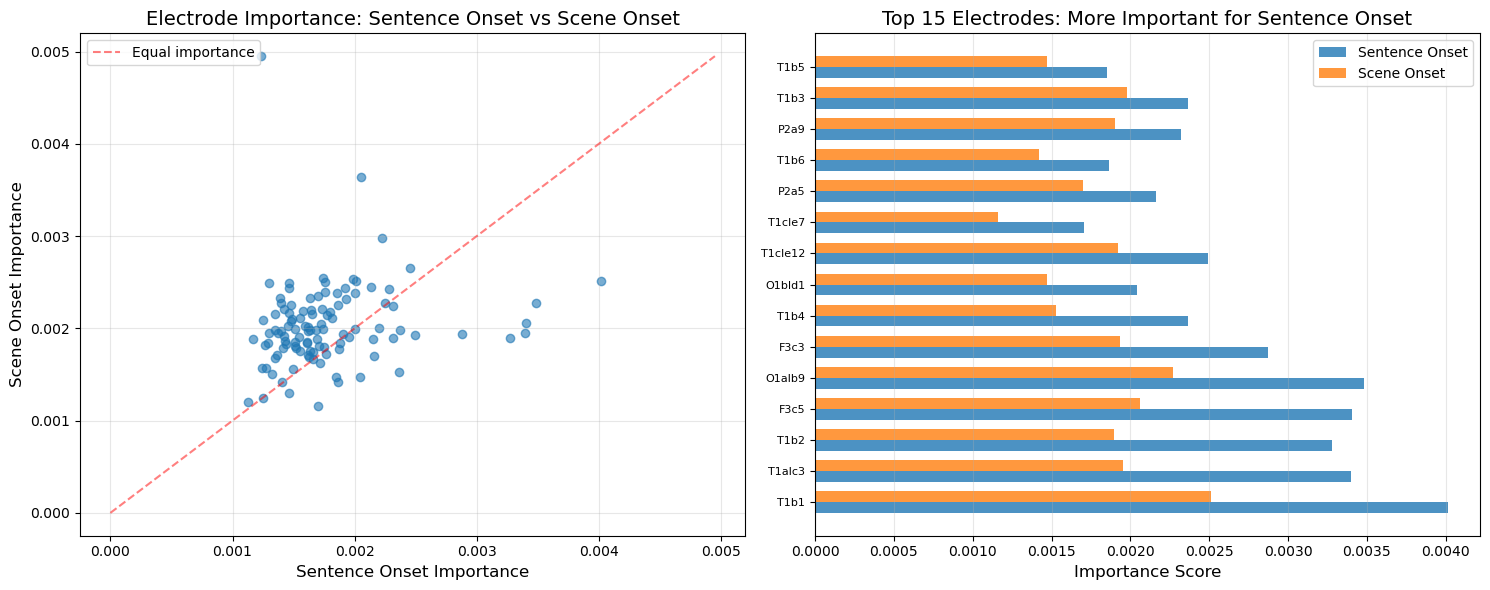


Results saved to 'electrode_importance_comparison.csv'


In [13]:
## Extract Electrode-Level Importance for Scene Onset vs Sentence Onset

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# Train classifiers for both tasks and extract electrode-level importance
def extract_electrode_importance(subject, trial_id, eval_name, folds, electrode_labels, n_time_samples):
    """
    Extract electrode-level importance from a trained classifier.
    
    Parameters:
    - subject: BrainTreebankSubject instance
    - trial_id: trial ID
    - eval_name: "onset" or "scene_onset"
    - folds: train/test splits
    - electrode_labels: list of electrode labels
    - n_time_samples: number of time samples per electrode
    
    Returns:
    - electrode_importance: array of importance scores per electrode (averaged across folds)
    """
    all_electrode_importances = []
    
    for fold_idx, fold in enumerate(folds):
        train_dataset = fold["train_dataset"]
        test_dataset = fold["test_dataset"]
        
        train_dataset.dataset.output_dict = False
        test_dataset.dataset.output_dict = False
        
        # Convert to numpy arrays
        X_train = np.array([item[0].flatten() for item in train_dataset], dtype=np.float32)
        y_train = np.array([item[1] for item in train_dataset])
        
        # Standardize
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        
        # Train classifier
        clf = LogisticRegression(random_state=42, max_iter=1000, tol=1e-3)
        clf.fit(X_train, y_train)
        
        # Extract coefficients (weights)
        # For binary classification, clf.coef_ is shape (1, n_features)
        # We take the absolute value to get importance regardless of sign
        coef = np.abs(clf.coef_[0])  # Shape: (n_electrodes * n_time_samples,)
        
        # Reshape to (n_electrodes, n_time_samples)
        coef_reshaped = coef.reshape(len(electrode_labels), n_time_samples)
        
        # Aggregate across time: use mean absolute weight per electrode
        electrode_importance = np.mean(coef_reshaped, axis=1)
        
        all_electrode_importances.append(electrode_importance)
        
        print(f"  Fold {fold_idx+1}: Trained {eval_name} classifier")
    
    # Average across folds
    electrode_importance_avg = np.mean(all_electrode_importances, axis=0)
    
    return electrode_importance_avg

# Generate splits for both tasks
folds_onset = neuroprobe_train_test_splits.generate_splits_within_session(
    subject, trial_id, "onset", dtype=torch.float32,
    output_indices=output_indices,
    start_neural_data_before_word_onset=start_neural_data_before_word_onset,
    end_neural_data_after_word_onset=end_neural_data_after_word_onset,
    lite=True
)

folds_scene = neuroprobe_train_test_splits.generate_splits_within_session(
    subject, trial_id, "scene_onset", dtype=torch.float32,
    output_indices=output_indices,
    start_neural_data_before_word_onset=start_neural_data_before_word_onset,
    end_neural_data_after_word_onset=end_neural_data_after_word_onset,
    lite=True
)

# Get dataset to know the shape
dataset_temp = BrainTreebankSubjectTrialBenchmarkDataset(
    subject, trial_id, dtype=torch.float32, eval_name="onset",
    output_indices=False,
    start_neural_data_before_word_onset=start_neural_data_before_word_onset,
    end_neural_data_after_word_onset=end_neural_data_after_word_onset,
    lite=True, output_dict=False
)

electrode_labels = dataset_temp.electrode_labels
n_electrodes = len(electrode_labels)
n_time_samples = dataset_temp[0][0].shape[1]  # Number of time samples

print(f"Extracting electrode importance for Sentence Onset...")
importance_onset = extract_electrode_importance(
    subject, trial_id, "onset", folds_onset, electrode_labels, n_time_samples
)

print(f"\nExtracting electrode importance for Scene Onset...")
importance_scene = extract_electrode_importance(
    subject, trial_id, "scene_onset", folds_scene, electrode_labels, n_time_samples
)

# Create comparison DataFrame
import pandas as pd

electrode_comparison = pd.DataFrame({
    'electrode': electrode_labels,
    'sentence_onset_importance': importance_onset,
    'scene_onset_importance': importance_scene,
    'difference': importance_onset - importance_scene,
    'ratio': importance_onset / (importance_scene + 1e-10)  # Add small epsilon to avoid division by zero
})

# Sort by difference to see which electrodes are more important for each task
print("\n" + "="*80)
print("Top 10 electrodes for SENTENCE ONSET (sorted by importance):")
print("="*80)
print(electrode_comparison.nlargest(10, 'sentence_onset_importance')[['electrode', 'sentence_onset_importance', 'scene_onset_importance']])

print("\n" + "="*80)
print("Top 10 electrodes for SCENE ONSET (sorted by importance):")
print("="*80)
print(electrode_comparison.nlargest(10, 'scene_onset_importance')[['electrode', 'sentence_onset_importance', 'scene_onset_importance']])

print("\n" + "="*80)
print("Electrodes MORE important for SENTENCE ONSET (difference > 0):")
print("="*80)
print(electrode_comparison.nlargest(10, 'difference')[['electrode', 'sentence_onset_importance', 'scene_onset_importance', 'difference']])

print("\n" + "="*80)
print("Electrodes MORE important for SCENE ONSET (difference < 0):")
print("="*80)
print(electrode_comparison.nsmallest(10, 'difference')[['electrode', 'sentence_onset_importance', 'scene_onset_importance', 'difference']])

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Scatter plot
axes[0].scatter(importance_onset, importance_scene, alpha=0.6)
axes[0].set_xlabel('Sentence Onset Importance', fontsize=12)
axes[0].set_ylabel('Scene Onset Importance', fontsize=12)
axes[0].set_title('Electrode Importance: Sentence Onset vs Scene Onset', fontsize=14)
axes[0].grid(True, alpha=0.3)
# Add diagonal line
max_val = max(importance_onset.max(), importance_scene.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Equal importance')
axes[0].legend()

# Plot 2: Bar plot of top differences
top_n = 15
top_sentence = electrode_comparison.nlargest(top_n, 'difference')
top_scene = electrode_comparison.nsmallest(top_n, 'difference')

x_pos = np.arange(top_n)
width = 0.35

axes[1].barh(x_pos - width/2, top_sentence['sentence_onset_importance'].values, 
             width, label='Sentence Onset', alpha=0.8)
axes[1].barh(x_pos + width/2, top_sentence['scene_onset_importance'].values, 
             width, label='Scene Onset', alpha=0.8)
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(top_sentence['electrode'].values, fontsize=8)
axes[1].set_xlabel('Importance Score', fontsize=12)
axes[1].set_title(f'Top {top_n} Electrodes: More Important for Sentence Onset', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Save results
electrode_comparison.to_csv('electrode_importance_comparison.csv', index=False)
print("\nResults saved to 'electrode_importance_comparison.csv'")

No electrodes found for right hemisphere
No electrodes found for right hemisphere


C:\Users\User\AppData\Local\Temp\ipykernel_2632\3245962553.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


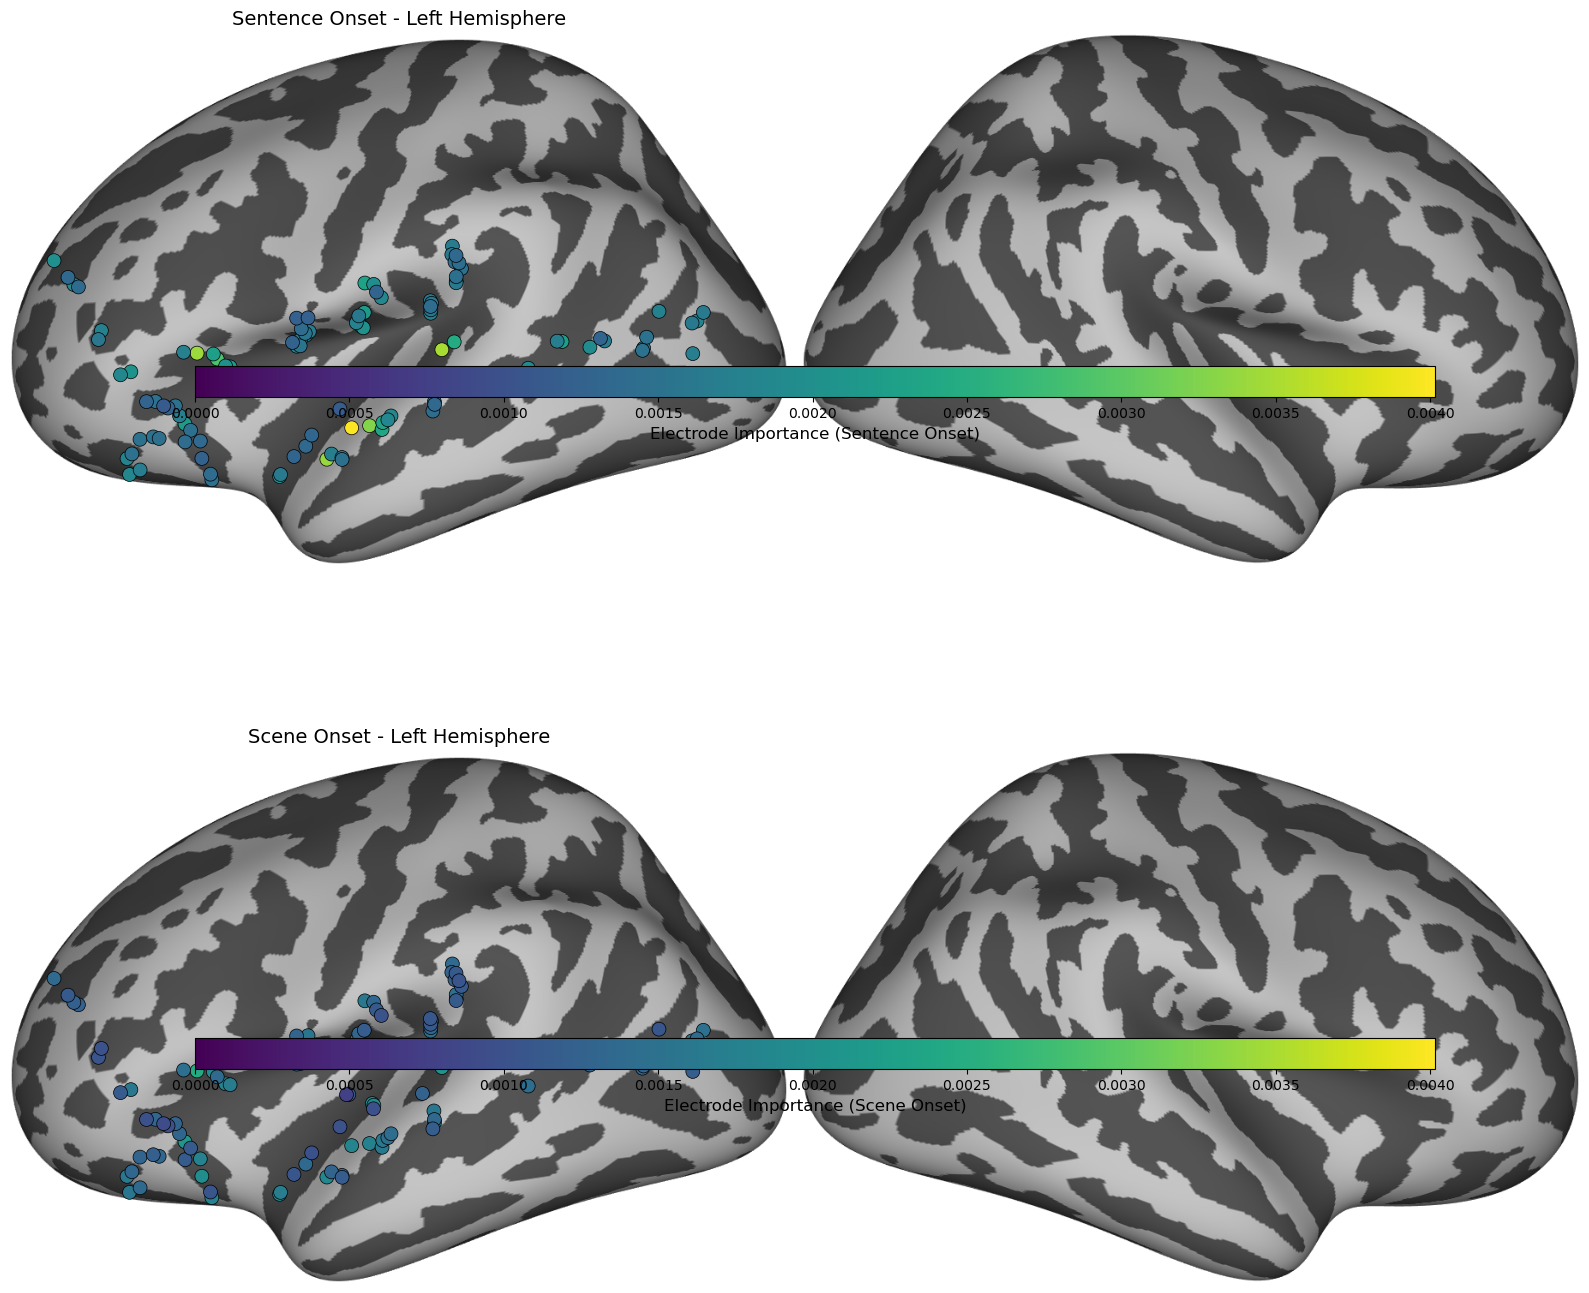

No electrodes found for right hemisphere


C:\Users\User\AppData\Local\Temp\ipykernel_2632\3245962553.py:185: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


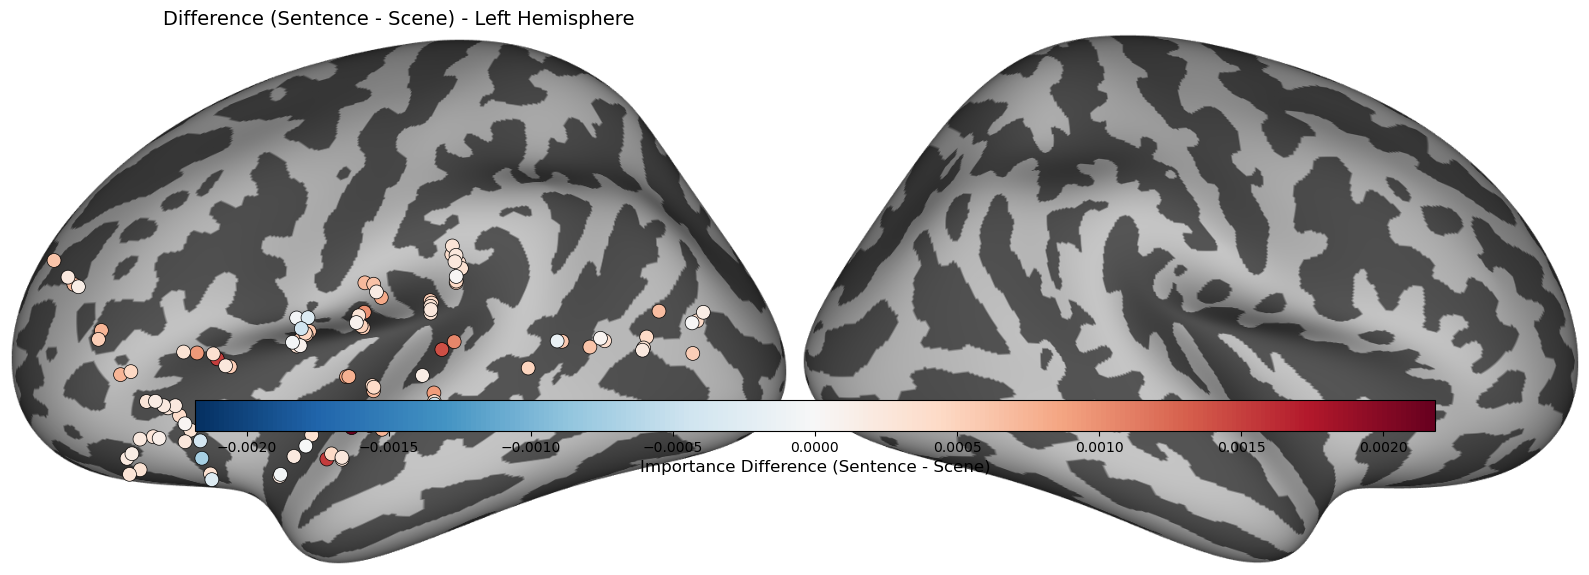

In [13]:
## Plot Electrode Locations Colored by Importance

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Set up paths (adjust to your system)
base_path = os.path.join(neuroprobe_config.ROOT_DIR, 'localization')
left_hem_file_name = 'left_hem_clean.png'
right_hem_file_name = 'right_hem_clean.png'
coords_file_name = 'elec_coords_full.csv'

# Load hemisphere images and coordinates
left_hem_img = plt.imread(os.path.join(base_path, left_hem_file_name))
right_hem_img = plt.imread(os.path.join(base_path, right_hem_file_name))
coords_df = pd.read_csv(os.path.join(base_path, coords_file_name))

# Process electrode IDs
split_elec_id = coords_df['ID'].str.split('-')
coords_df['Subject'] = [t[0] for t in split_elec_id]
coords_df['Electrode'] = [t[1] for t in split_elec_id]

# Scale coordinates (from the notebook)
matlab_xlim = (-108.0278, 108.0278)
matlab_ylim = (-72.9774, 72.9774)

x_scale = left_hem_img.shape[1] / (matlab_xlim[1] - matlab_xlim[0])
y_scale_l = left_hem_img.shape[0] / (matlab_ylim[1] - matlab_ylim[0])
y_scale_r = right_hem_img.shape[0] / (matlab_ylim[1] - matlab_ylim[0])

def scale(x, s, d):
    return -(x - d) * s

scaled_coords_df = coords_df.copy()
scaled_coords_df.loc[scaled_coords_df['Hemisphere'] == 1, 'X'] = coords_df.loc[coords_df['Hemisphere'] == 1, 'X'].apply(lambda x: scale(x, x_scale, matlab_xlim[1]))
scaled_coords_df.loc[scaled_coords_df['Hemisphere'] == 1, 'Y'] = coords_df.loc[coords_df['Hemisphere'] == 1, 'Y'].apply(lambda x: scale(x, y_scale_l, matlab_ylim[1]))
scaled_coords_df.loc[scaled_coords_df['Hemisphere'] == 0, 'X'] = coords_df.loc[coords_df['Hemisphere'] == 0, 'X'].apply(lambda x: -scale(x, y_scale_r, matlab_xlim[0]))
scaled_coords_df.loc[scaled_coords_df['Hemisphere'] == 0, 'Y'] = coords_df.loc[coords_df['Hemisphere'] == 0, 'Y'].apply(lambda x: scale(x, y_scale_r, matlab_ylim[1]))

def plot_hemisphere_axis(electrode_importance_dict, ax=None, hemisphere="left", title=None, vmin=None, vmax=None, cmap='viridis'):
    """
    Plot electrodes on a hemisphere colored by importance.
    
    Parameters:
    - electrode_importance_dict: dict mapping electrode_label -> importance_value
    - ax: matplotlib axis
    - hemisphere: "left" or "right"
    - title: title for the plot
    - vmin, vmax: color scale limits
    - cmap: colormap to use
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    
    ax.set_aspect('equal')
    
    if hemisphere == "left":
        ax.imshow(left_hem_img)
        hem_index = 1
    elif hemisphere == "right":
        ax.imshow(right_hem_img)
        hem_index = 0
    else:
        raise ValueError("hemisphere must be 'left' or 'right'")
    
    ax.axis('off')
    
    # Get coordinates for this subject and hemisphere
    subject_id = subject.subject_id  # Use your subject
    subject_str = f'sub_{subject_id}'
    
    all_x, all_y, all_colors = [], [], []
    
    for electrode_label, importance in electrode_importance_dict.items():
        # Find coordinates for this electrode
        coords = scaled_coords_df[
            (scaled_coords_df.Subject == subject_str) & 
            (scaled_coords_df.Electrode == electrode_label) & 
            (scaled_coords_df.Hemisphere == hem_index)
        ]
        
        if len(coords) > 0:
            x = coords['X'].values[0]
            y = coords['Y'].values[0]
            all_x.append(x)
            all_y.append(y)
            all_colors.append(importance)
    
    if len(all_x) == 0:
        print(f"No electrodes found for {hemisphere} hemisphere")
        return None
    
    all_x = np.array(all_x)
    all_y = np.array(all_y)
    all_colors = np.array(all_colors)
    
    # Set color scale if not provided
    if vmin is None:
        vmin = np.min(all_colors)
    if vmax is None:
        vmax = np.max(all_colors)
    
    # Sort by color so lower values appear on top
    sort_idx = np.argsort(all_colors)[::-1]
    
    sc = ax.scatter(all_x[sort_idx], all_y[sort_idx], 
                   c=all_colors[sort_idx], 
                   vmin=vmin, vmax=vmax, 
                   s=100, 
                   edgecolors='black', 
                   linewidths=0.5,
                   cmap=cmap)
    
    if title:
        ax.set_title(title, fontsize=14, pad=10)
    
    return sc

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# Plot 1: Sentence Onset Importance
ax = axes[0, 0]
sentence_colors = {label: imp for label, imp in zip(electrode_labels, importance_onset)}
sc1 = plot_hemisphere_axis(sentence_colors, ax=ax, hemisphere="left", 
                           title="Sentence Onset - Left Hemisphere", 
                           vmin=0, vmax=np.max([importance_onset.max(), importance_scene.max()]))

ax = axes[0, 1]
sc2 = plot_hemisphere_axis(sentence_colors, ax=ax, hemisphere="right", 
                          title="Sentence Onset - Right Hemisphere",
                          vmin=0, vmax=np.max([importance_onset.max(), importance_scene.max()]))

# Plot 2: Scene Onset Importance
ax = axes[1, 0]
scene_colors = {label: imp for label, imp in zip(electrode_labels, importance_scene)}
sc3 = plot_hemisphere_axis(scene_colors, ax=ax, hemisphere="left", 
                           title="Scene Onset - Left Hemisphere",
                           vmin=0, vmax=np.max([importance_onset.max(), importance_scene.max()]))

ax = axes[1, 1]
sc4 = plot_hemisphere_axis(scene_colors, ax=ax, hemisphere="right", 
                          title="Scene Onset - Right Hemisphere",
                          vmin=0, vmax=np.max([importance_onset.max(), importance_scene.max()]))

# Add colorbars
cbar1 = plt.colorbar(sc1, ax=axes[0, :], orientation='horizontal', pad=0.1, aspect=40)
cbar1.set_label('Electrode Importance (Sentence Onset)', fontsize=12)

cbar2 = plt.colorbar(sc3, ax=axes[1, :], orientation='horizontal', pad=0.1, aspect=40)
cbar2.set_label('Electrode Importance (Scene Onset)', fontsize=12)

plt.tight_layout()
plt.savefig('electrode_importance_brain_plot.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Alternative: Plot the DIFFERENCE between tasks
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Calculate difference (sentence - scene)
importance_diff = importance_onset - importance_scene
diff_colors = {label: diff for label, diff in zip(electrode_labels, importance_diff)}

# Use diverging colormap for difference
ax = axes[0]
sc_left = plot_hemisphere_axis(diff_colors, ax=ax, hemisphere="left", 
                               title="Difference (Sentence - Scene) - Left Hemisphere",
                               vmin=-np.abs(importance_diff).max(), 
                               vmax=np.abs(importance_diff).max(),
                               cmap='RdBu_r')

ax = axes[1]
sc_right = plot_hemisphere_axis(diff_colors, ax=ax, hemisphere="right", 
                               title="Difference (Sentence - Scene) - Right Hemisphere",
                               vmin=-np.abs(importance_diff).max(), 
                               vmax=np.abs(importance_diff).max(),
                               cmap='RdBu_r')

# Add colorbar
cbar = plt.colorbar(sc_left, ax=axes, orientation='horizontal', pad=0.1, aspect=40)
cbar.set_label('Importance Difference (Sentence - Scene)', fontsize=12)

plt.tight_layout()
plt.savefig('electrode_importance_difference_brain_plot.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
from neuroprobe import BrainTreebankSubjectTrialBenchmarkDataset
import numpy as np

dataset_onset = BrainTreebankSubjectTrialBenchmarkDataset(
    subject,
    trial_id,
    dtype=torch.float32,
    eval_name="onset",
    output_indices=False,
    start_neural_data_before_word_onset=start_neural_data_before_word_onset,
    end_neural_data_after_word_onset=end_neural_data_after_word_onset,
    lite=True,
    output_dict=False,
)

# Process in batches to avoid MemoryError
batch_size = 200  # Adjust based on your available memory
dataset_len = len(dataset_onset)

# Initialize counters for accuracy calculation
correct_predictions = 0
total_predictions = 0
all_probs = []  # Store probabilities if needed (or process incrementally)

print(f"Processing {dataset_len} samples in batches of {batch_size}...")

for batch_start in range(0, dataset_len, batch_size):
    batch_end = min(batch_start + batch_size, dataset_len)
    
    # Load only this batch into memory
    X_batch = np.array([dataset_onset[i][0].flatten() for i in range(batch_start, batch_end)])
    y_batch = np.array([dataset_onset[i][1] for i in range(batch_start, batch_end)])
    
    # Transform this batch
    X_batch_std = scaler.transform(X_batch.astype(np.float32))
    
    # Get predictions and probabilities for this batch
    y_pred_batch = clf.predict(X_batch_std)
    probs_batch = clf.predict_proba(X_batch_std)
    
    # Accumulate results
    correct_predictions += np.sum(y_pred_batch == y_batch)
    total_predictions += len(y_batch)
    all_probs.append(probs_batch)
    
    if (batch_start // batch_size + 1) % 10 == 0:
        print(f"  Processed {batch_end}/{dataset_len} samples...")

# Calculate overall accuracy
acc_onset = correct_predictions / total_predictions

# Concatenate probabilities if needed (or process incrementally)
probs_onset = np.vstack(all_probs)

print(f"\nOverall accuracy on onset set: {acc_onset:.3f}")
print(f"First five probability vectors:\n{probs_onset[:5]}")

Processing 3500 samples in batches of 200...
  Processed 2000/3500 samples...

Overall accuracy on onset set: 0.704
First five probability vectors:
[[5.06021619e-04 9.99493978e-01]
 [9.96276702e-01 3.72329779e-03]
 [1.29366066e-02 9.87063393e-01]
 [9.99972962e-01 2.70381826e-05]
 [1.14359880e-04 9.99885640e-01]]


In [12]:
# Check class distribution in onset dataset
y_onset_all = np.array([dataset_onset[i][1] for i in range(len(dataset_onset))])
print(f"Class distribution: {np.bincount(y_onset_all)}")
print(f"Class proportions: {np.bincount(y_onset_all) / len(y_onset_all)}")

Class distribution: [1750 1750]
Class proportions: [0.5 0.5]


In [13]:
from scipy.stats import pearsonr, spearmanr
import numpy as np

# Reuse the trained scene-onset classifier and its scaler
# clf_scene, scaler_scene already defined above

dataset_onset_full = BrainTreebankSubjectTrialBenchmarkDataset(
    subject,
    trial_id,
    dtype=torch.float32,
    eval_name="onset",
    output_indices=False,
    start_neural_data_before_word_onset=start_neural_data_before_word_onset,
    end_neural_data_after_word_onset=end_neural_data_after_word_onset,
    lite=True,
    output_dict=False,
)

batch_size = 200  # tune if you still hit RAM limits
all_scene_probs = []
all_onset_labels = []

print(f"Computing correlations on {len(dataset_onset_full)} onset samples...")

for start in range(0, len(dataset_onset_full), batch_size):
    end = min(start + batch_size, len(dataset_onset_full))
    batch = [dataset_onset_full[i] for i in range(start, end)]
    X_batch = np.array([item[0].flatten() for item in batch], dtype=np.float32)
    y_batch = np.array([item[1] for item in batch], dtype=np.int16)

    X_batch_std = scaler.transform(X_batch)
    scene_probs = clf.predict_proba(X_batch_std)[:, 1]

    all_scene_probs.append(scene_probs)
    all_onset_labels.append(y_batch)

scene_probs = np.concatenate(all_scene_probs)
onset_labels = np.concatenate(all_onset_labels)

pearson_r, pearson_p = pearsonr(scene_probs, onset_labels)
spearman_r, spearman_p = spearmanr(scene_probs, onset_labels)

print(f"Pearson r: {pearson_r:.3f} (p={pearson_p:.3e})")
print(f"Spearman r: {spearman_r:.3f} (p={spearman_p:.3e})")

Computing correlations on 3500 onset samples...
Pearson r: 0.427 (p=1.842e-155)
Spearman r: 0.446 (p=4.890e-171)


In [21]:
from neuroprobe import BrainTreebankSubjectTrialBenchmarkDataset
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Load both datasets with output_indices=True to see which time windows they use
dataset_onset_indices = BrainTreebankSubjectTrialBenchmarkDataset(
    subject, trial_id, dtype=torch.float32, eval_name="onset",
    output_indices=True,  # Get indices instead of data
    start_neural_data_before_word_onset=start_neural_data_before_word_onset,
    end_neural_data_after_word_onset=end_neural_data_after_word_onset,
    lite=True, output_dict=False
)

dataset_scene_indices = BrainTreebankSubjectTrialBenchmarkDataset(
    subject, trial_id, dtype=torch.float32, eval_name="scene_onset",
    output_indices=True,
    start_neural_data_before_word_onset=start_neural_data_before_word_onset,
    end_neural_data_after_word_onset=end_neural_data_after_word_onset,
    lite=True, output_dict=False
)

# Get all indices and labels
onset_indices = [(dataset_onset_indices[i][0], dataset_onset_indices[i][1]) for i in range(len(dataset_onset_indices))]
onset_labels = [dataset_onset_indices[i][1] for i in range(len(dataset_onset_indices))]

scene_indices = [(dataset_scene_indices[i][0], dataset_scene_indices[i][1]) for i in range(len(dataset_scene_indices))]
scene_labels = [dataset_scene_indices[i][1] for i in range(len(dataset_scene_indices))]

# Find overlapping time windows
onset_index_set = set(onset_indices)
scene_index_set = set(scene_indices)
overlapping_indices = onset_index_set & scene_index_set

print(f"Onset dataset: {len(onset_indices)} samples")
print(f"Scene_onset dataset: {len(scene_indices)} samples")
print(f"Overlapping time windows: {len(overlapping_indices)} samples")
print(f"Overlap percentage: {len(overlapping_indices) / max(len(onset_indices), len(scene_indices)) * 100:.1f}%")

# Now load the actual data for overlapping samples and compare
if len(overlapping_indices) > 0:
    # Get data for overlapping samples
    dataset_onset_data = BrainTreebankSubjectTrialBenchmarkDataset(
        subject, trial_id, dtype=torch.float32, eval_name="onset",
        output_indices=False,
        start_neural_data_before_word_onset=start_neural_data_before_word_onset,
        end_neural_data_after_word_onset=end_neural_data_after_word_onset,
        lite=True, output_dict=False
    )
    
    dataset_scene_data = BrainTreebankSubjectTrialBenchmarkDataset(
        subject, trial_id, dtype=torch.float32, eval_name="scene_onset",
        output_indices=False,
        start_neural_data_before_word_onset=start_neural_data_before_word_onset,
        end_neural_data_after_word_onset=end_neural_data_after_word_onset,
        lite=True, output_dict=False
    )
    
    # Find matching samples and compare their neural data
    onset_idx_to_pos = {idx: i for i, idx in enumerate(onset_indices)}
    scene_idx_to_pos = {idx: i for i, idx in enumerate(scene_indices)}
    
    # Sample a subset for comparison (to avoid memory issues)
    sample_size = min(500, len(overlapping_indices))
    overlapping_list = list(overlapping_indices)[:sample_size]
    
    correlations = []
    cosine_sims = []
    label_matches = []
    
    print(f"\nComparing neural data for {sample_size} overlapping samples...")
    
    for idx in overlapping_list:
        onset_pos = onset_idx_to_pos[idx]
        scene_pos = scene_idx_to_pos[idx]
        
        # Get the neural data
        onset_data = dataset_onset_data[onset_pos][0].flatten().numpy()
        scene_data = dataset_scene_data[scene_pos][0].flatten().numpy()
        
        # Get labels
        onset_label = dataset_onset_data[onset_pos][1]
        scene_label = dataset_scene_data[scene_pos][1]
        label_matches.append(1 if onset_label == scene_label else 0)
        
        # Compute correlation
        corr, _ = pearsonr(onset_data, scene_data)
        correlations.append(corr)
        
        # Compute cosine similarity
        cos_sim = cosine_similarity([onset_data], [scene_data])[0][0]
        cosine_sims.append(cos_sim)
    
    print(f"\nNeural Data Similarity Metrics:")
    print(f"  Mean Pearson correlation: {np.mean(correlations):.3f} (std: {np.std(correlations):.3f})")
    print(f"  Mean Cosine similarity: {np.mean(cosine_sims):.3f} (std: {np.std(cosine_sims):.3f})")
    print(f"  Label agreement: {np.mean(label_matches)*100:.1f}% ({np.sum(label_matches)}/{len(label_matches)})")
    
    # Check if data is nearly identical
    if np.mean(correlations) > 0.99:
        print("\n⚠️  WARNING: Neural data is nearly identical (>0.99 correlation)!")
    elif np.mean(correlations) > 0.9:
        print("\n⚠️  Neural data is very similar (>0.9 correlation)")
    else:
        print(f"\n✓ Neural data shows moderate similarity ({np.mean(correlations):.3f} correlation)")
else:
    print("\n⚠️  No overlapping time windows found - datasets use different time points!")

Onset dataset: 3500 samples
Scene_onset dataset: 1768 samples
Overlapping time windows: 152 samples
Overlap percentage: 4.3%

Comparing neural data for 152 overlapping samples...

Neural Data Similarity Metrics:
  Mean Pearson correlation: 1.000 (std: 0.000)
  Mean Cosine similarity: 1.000 (std: 0.000)
  Label agreement: 100.0% (152/152)

⚠️  WARNING: Neural data is nearly identical (>0.99 correlation)!


In [25]:
## Compare Onset vs Scene Onset Classifier Predictions

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr
import numpy as np

# Train classifier on "onset" (sentence onset)
eval_name_onset = "onset"
folds_onset = neuroprobe_train_test_splits.generate_splits_within_session(
    subject, trial_id, eval_name_onset, dtype=torch.float32,
    output_indices=output_indices,
    start_neural_data_before_word_onset=start_neural_data_before_word_onset,
    end_neural_data_after_word_onset=end_neural_data_after_word_onset,
    lite=True
)

dataset_onset = BrainTreebankSubjectTrialBenchmarkDataset(
    subject, trial_id, dtype=torch.float32, eval_name="onset",
    output_indices=output_indices,
    start_neural_data_before_word_onset=start_neural_data_before_word_onset,
    end_neural_data_after_word_onset=end_neural_data_after_word_onset,
    lite=True, output_dict=False
)

dataset_scene = BrainTreebankSubjectTrialBenchmarkDataset(
    subject, trial_id, dtype=torch.float32, eval_name="scene_onset",
    output_indices=output_indices,
    start_neural_data_before_word_onset=start_neural_data_before_word_onset,
    end_neural_data_after_word_onset=end_neural_data_after_word_onset,
    lite=True, output_dict=False
)

# Generate splits
folds_onset = neuroprobe_train_test_splits.generate_splits_within_session(
    subject, trial_id, "onset", dtype=torch.float32,
    output_indices=output_indices,
    start_neural_data_before_word_onset=start_neural_data_before_word_onset,
    end_neural_data_after_word_onset=end_neural_data_after_word_onset,
    lite=True
)

folds_scene = neuroprobe_train_test_splits.generate_splits_within_session(
    subject, trial_id, "scene_onset", dtype=torch.float32,
    output_indices=output_indices,
    start_neural_data_before_word_onset=start_neural_data_before_word_onset,
    end_neural_data_after_word_onset=end_neural_data_after_word_onset,
    lite=True
)

correlations = []

# For each fold, get predictions on the same test samples
for fold_idx in range(len(folds_onset)):
    print(f"Fold {fold_idx+1} of {len(folds_onset)}")
    
    # Get datasets
    fold_onset = folds_onset[fold_idx]
    fold_scene = folds_scene[fold_idx]
    
    train_dataset_onset = fold_onset["train_dataset"]
    test_dataset_onset = fold_onset["test_dataset"]
    train_dataset_scene = fold_scene["train_dataset"]
    test_dataset_scene = fold_scene["test_dataset"]
    
    # Set output_dict to False
    train_dataset_onset.dataset.output_dict = False
    test_dataset_onset.dataset.output_dict = False
    train_dataset_scene.dataset.output_dict = False
    test_dataset_scene.dataset.output_dict = False
    
    # Prepare data for onset classifier
    X_train_onset = np.array([item[0].flatten() for item in train_dataset_onset])
    y_train_onset = np.array([item[1] for item in train_dataset_onset])
    X_test_onset = np.array([item[0].flatten() for item in test_dataset_onset])
    y_test_onset = np.array([item[1] for item in test_dataset_onset])
    
    # Prepare data for scene_onset classifier
    X_train_scene = np.array([item[0].flatten() for item in train_dataset_scene])
    y_train_scene = np.array([item[1] for item in train_dataset_scene])
    X_test_scene = np.array([item[0].flatten() for item in test_dataset_scene])
    y_test_scene = np.array([item[1] for item in test_dataset_scene])
    
    # Standardize
    # Standardize (convert to float32 first to save memory)
    # scaler_onset = StandardScaler()
    # X_train_onset = scaler_onset.fit_transform(X_train_onset.astype(np.float32))
    # X_test_onset = scaler_onset.transform(X_test_onset.astype(np.float32))

    # scaler_scene = StandardScaler()
    # X_train_scene = scaler_scene.fit_transform(X_train_scene.astype(np.float32))
    # X_test_scene = scaler_scene.transform(X_test_scene.astype(np.float32))


    # Standardize in batches to save memory
    from sklearn.preprocessing import StandardScaler
    import gc

    def standardize_in_batches(X, scaler=None, batch_size=500):
        if scaler is None:
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X[:batch_size].astype(np.float32))
            for i in range(batch_size, len(X), batch_size):
                batch = X[i:i+batch_size].astype(np.float32)
                X_scaled = np.vstack([X_scaled, scaler.transform(batch)])
            return X_scaled, scaler
        else:
            X_scaled = scaler.transform(X[:batch_size].astype(np.float32))
            for i in range(batch_size, len(X), batch_size):
                batch = X[i:i+batch_size].astype(np.float32)
                X_scaled = np.vstack([X_scaled, scaler.transform(batch)])
            return X_scaled

    # Use it like this:
    X_train_onset, scaler_onset = standardize_in_batches(X_train_onset)
    X_test_onset = standardize_in_batches(X_test_onset, scaler_onset)
    X_train_scene, scaler_scene = standardize_in_batches(X_train_scene)
    X_test_scene = standardize_in_batches(X_test_scene, scaler_scene)
    
    # Train classifiers
    clf_onset = LogisticRegression(random_state=42, max_iter=1000, tol=1e-3)
    clf_onset.fit(X_train_onset, y_train_onset)
    
    clf_scene = LogisticRegression(random_state=42, max_iter=1000, tol=1e-3)
    clf_scene.fit(X_train_scene, y_train_scene)
    
    # Get prediction probabilities (use probabilities for better correlation)
    probs_onset = clf_onset.predict_proba(X_test_onset)[:, 1]  # Probability of class 1
    probs_scene = clf_scene.predict_proba(X_test_scene)[:, 1]  # Probability of class 1
    
    # Calculate correlations
    pearson_corr, pearson_p = pearsonr(probs_onset, probs_scene)
    spearman_corr, spearman_p = spearmanr(probs_onset, probs_scene)
    
    correlations.append({
        'fold': fold_idx + 1,
        'pearson_r': pearson_corr,
        'pearson_p': pearson_p,
        'spearman_r': spearman_corr,
        'spearman_p': spearman_p
    })
    
    print(f"  Pearson correlation: {pearson_corr:.3f} (p={pearson_p:.4f})")
    print(f"  Spearman correlation: {spearman_corr:.3f} (p={spearman_p:.4f})")

# Average correlations across folds
avg_pearson = np.mean([c['pearson_r'] for c in correlations])
avg_spearman = np.mean([c['spearman_r'] for c in correlations])
print(f"\nAverage Pearson correlation: {avg_pearson:.3f}")
print(f"Average Spearman correlation: {avg_spearman:.3f}")

Fold 1 of 2


MemoryError: Unable to allocate 1.25 GiB for an array with shape (1500, 223232) and data type float32

In [21]:
y_test

array([1, 0, 1, ..., 0, 1, 0])

In [20]:
np.log10(X_train.size * 8)

9.494884485922654

In [7]:
import json

with open(r"C:\Users\User\Documents\UNI\BRAIN\braintree\scene_annotations\scene_annotations.json") as f:
    data = json.load(f)

# See what type of object it is
print(type(data))

# For dicts
if isinstance(data, dict):
    print("Top-level keys:", list(data.keys())[:20])

# For lists
elif isinstance(data, list):
    print("Number of items:", len(data))
    print("Example item:", json.dumps(data[0], indent=2)[:500])

<class 'list'>
Number of items: 1
Example item: {
  "user:annotations:v3::jkdewit": {
    "{\"startTime\":3813,\"endTime\":3813,\"label\":\"\"}": "3813.0",
    "{\"startTime\":3812,\"endTime\":3812,\"label\":\"\"}": "3812.0",
    "{\"startTime\":3811,\"endTime\":3811,\"label\":\"\"}": "3811.0",
    "{\"startTime\":3810,\"endTime\":3810,\"label\":\"\"}": "3810.0",
    "{\"startTime\":3809,\"endTime\":3809,\"label\":\"\"}": "3809.0",
    "{\"startTime\":3808,\"endTime\":3808,\"label\":\"#\"}": "3808.0",
    "{\"startTime\":3808,\"endTime\":3808


In [9]:
import json

def explore_json(obj, indent=0, max_depth=3):
    """Recursively print JSON structure up to a given depth."""
    prefix = "  " * indent
    if indent > max_depth:
        print(prefix + "...")
        return

    if isinstance(obj, dict):
        print(f"{prefix}dict ({len(obj)} keys)")
        for k, v in list(obj.items())[:5]:  # show only first few keys
            print(f"{prefix}  '{k}': ", end="")
            explore_json(v, indent + 1, max_depth)
        if len(obj) > 5:
            print(prefix + "  ...")
    elif isinstance(obj, list):
        print(f"{prefix}list ({len(obj)} items)")
        if obj:
            explore_json(obj[0], indent + 1, max_depth)
    else:
        print(prefix + f"{type(obj).__name__} -> {repr(obj)[:60]}")

# Example usage
with open(r"C:\Users\User\Documents\UNI\BRAIN\braintree\scene_annotations\scene_annotations.json") as f:
    data = json.load(f)

explore_json(data)


list (1 items)
  dict (70 keys)
    'user:annotations:v3::jkdewit':     dict (46935 keys)
      '{"startTime":3813,"endTime":3813,"label":""}':       str -> '3813.0'
      '{"startTime":3812,"endTime":3812,"label":""}':       str -> '3812.0'
      '{"startTime":3811,"endTime":3811,"label":""}':       str -> '3811.0'
      '{"startTime":3810,"endTime":3810,"label":""}':       str -> '3810.0'
      '{"startTime":3809,"endTime":3809,"label":""}':       str -> '3809.0'
      ...
    'movie:annotations:v3:cars-2:jkdewit':     dict (2433 keys)
      '{"startTime":2433,"endTime":2433,"label":"#"}':       str -> '2433.0'
      '{"startTime":2432,"endTime":2432,"label":"#"}':       str -> '2432.0'
      '{"startTime":2431,"endTime":2431,"label":"#"}':       str -> '2431.0'
      '{"startTime":2430,"endTime":2430,"label":"#"}':       str -> '2430.0'
      '{"startTime":2429,"endTime":2429,"label":"#"}':       str -> '2429.0'
      ...
    'movie:annotations:v3:thor-ragnarok:stanford':     dict (